# Viscoelastic + Modified Cam-Clay — Below / Above Yield Point
## Clay-Rich Formation — Brine vs H₂ — 100 / 200 / 300 bar

---
### Physical model
Couples a **Kelvin–Voigt viscoelastic unit** with **MCC elasto-plasticity**.

| Strain component | Active zone | Equation |
|---|---|---|
| Elastic | Always | ε_el = q / E_avg |
| Viscoelastic | Always | ε_ve = (q/E₂)(1−exp(−E₂t/η₁)) |
| Plastic (MCC) | Above yield (F>0) only | return-mapping |

### MCC yield criterion
$$F(p', q, p_c) = p'^2 - p' p_c + q^2/M^2 \begin{cases} <0 & \text{below yield} \\ =0 & \text{on surface} \\ >0 & \text{above yield} \end{cases}$$

### Part A — Viscoelastic strain (Kelvin-Voigt)

$$\varepsilon^{ve} = \frac{q}{E_2}\left(1-\exp\left(\frac{-E_2}{\eta_1}t\right)\right)$$

| Symbol | Meaning |
|---|---|
| $E_2$ | Spring stiffness [GPa] |
| $\eta_1$ | Dashpot viscosity [GPa·s] |
| $\tau=\eta_1/E_2$ | Retardation time |

- $t=0$: no VE strain — dashpot resists
- $t\to\infty$: $\varepsilon^{ve}\to q/E_2$ — dashpot relaxed
- $t=\tau$: 63% of maximum

---

### Part B — MCC below/above yield

$$F = p'^2 - p'p_c + q^2/M^2$$

| Condition | Zone | Active strains |
|---|---|---|
| $F<0$ | Below yield | elastic + VE |
| $F=0$ | Yield surface | onset of plastic |
| $F>0$ | Above yield | elastic + VE + **plastic** |

$$\varepsilon_{total}=\underbrace{q/E_{avg}}_{elastic}+\underbrace{(q/E_2)(1-e^{-E_2 t/\eta_1})}_{viscoelastic}+\underbrace{\varepsilon^{pl}_{MCC}}_{\text{only if }F>0}$$

---


### Notebook structure
| Cell | Content |
|---|---|
| 01 | Imports & global style |
| 02 | Output directory & `save_fig` helper |
| 03 | Material parameters (`table_guess`) |
| 04 | Loading conditions, colors, axis labels |
| 05 | Physics functions (VE, elastic, yield surface, stress path) |
| 06 | Cyclic MCC+VE simulator (`simulate_cyclic_full`) |
| 07 | Run all simulations |
| 08 | Fig 01 — Stress path: below / above yield |
| 09 | Fig 02 — Strain decomposition along loading path |
| 10 | Fig 03 — Yield function F along stress path |
| 11 | Fig 04 — 8-cycle loops all cases |
| 12 | Fig 05 — 8-cycle loops Brine vs H₂ |
| 13 | Fig 06 — p_c hardening over 8 cycles |
| 14 | Fig 07 — Below yield: elastic + VE vs q |
| 15 | Fig 08 — VE creep build-up vs time |
| 16 | Fig 09 — Elastic vs VE at different load durations |
| 17 | Fig 10 — Cycle 1: below / above yield coloured |
| 18 | Fig 11 — Strain components per cycle (stacked bars) |
| 19 | Fig 12 — VE recovery: load → hold → unload → recover |
| 20 | Summary table & figure index |

### All outputs saved to `Output_VE_MCCM_YP_Clay_Rich/`


## Cell 01 — Imports & Global Plotting Style

### Purpose
Load all required Python libraries and set publication-quality Matplotlib defaults shared by every figure cell.

### What you will see
- `"Imports OK"` — no figures produced here.

### Libraries loaded
| Library | Role |
|---|---|
| `numpy` | Arrays, exp, sqrt, linspace |
| `matplotlib.pyplot` | Core plotting engine |
| `matplotlib.ticker` | Axis tick formatters |
| `matplotlib.patches` | Custom patch handles |
| `matplotlib.lines` | Line2D for legend handles |
| `os` | Folder creation and path handling |


In [1]:
# =============================================================================
# CELL 01 — IMPORTS & GLOBAL PLOTTING STYLE
# =============================================================================

import os                              # folder creation and path handling
import numpy as np                     # arrays, exp, sqrt, linspace, etc.
import matplotlib.pyplot as plt        # core 2-D figure / axes engine
import matplotlib.ticker as mticker    # tick locators and formatters
import matplotlib.patches as mpatches  # patch objects for custom legends
from matplotlib.lines import Line2D    # Line2D for manual legend handles

# ── Global Matplotlib style — publication quality ─────────────────────────────
plt.rcParams.update({
    'font.size'        : 10,           # base font size for all text
    'axes.labelsize'   : 11,           # axis label font size
    'axes.labelweight' : 'bold',       # axis labels in bold
    'axes.titlesize'   : 11,           # subplot title font size
    'axes.titleweight' : 'bold',       # subplot titles in bold
    'legend.fontsize'  : 8.5,          # legend entry font size
    'figure.dpi'       : 120,          # screen render resolution
    'savefig.dpi'      : 300,          # saved-file resolution (publication)
    'axes.grid'        : True,         # background grid on every axis
    'grid.alpha'       : 0.30,         # semi-transparent grid lines
})

print("Imports OK")                    # confirm all imports completed


Imports OK


## Cell 02 — Output Directory & `save_fig` Helper

### Purpose
Create **`Output_VE_MCCM_YP_Clay_Rich/`** on disk and define `save_fig()` used by every figure cell.

### What you will see
- `"Output directory ready: Output_VE_MCCM_YP_Clay_Rich"` — no figures produced here.

### File naming convention
Each figure cell sets `CELL_NAME = "CellXX"` before calling `save_fig()`.  
Resulting filenames: `CellXX_FigYY_Name.pdf` and `CellXX_FigYY_Name.png`


In [2]:
# =============================================================================
# CELL 02 — OUTPUT DIRECTORY & FIGURE-SAVE HELPER
# =============================================================================

OUTPUT_DIR = "Output_VE_MCCM_YP_Clay_Rich"            # top-level folder for all saved figures
os.makedirs(OUTPUT_DIR, exist_ok=True) # create folder; no error if already exists

CELL_NAME  = "Cell02"                  # default; each figure cell overrides this

def save_fig(fig_name):
    """Save the current matplotlib figure to OUTPUT_DIR.

    Reads global CELL_NAME to build the filename prefix.
    Saves both PDF (vector) and PNG (300 dpi) versions.

    Parameters
    ----------
    fig_name : str  Descriptive suffix, e.g. 'Fig01_StressPath_BelowAboveYield'.
    """
    base     = f"{CELL_NAME}_{fig_name}"              # e.g. Cell08_Fig01_...
    pdf_path = os.path.join(OUTPUT_DIR, base + ".pdf")   # full PDF path
    png_path = os.path.join(OUTPUT_DIR, base + ".png")   # full PNG path
    plt.savefig(pdf_path, bbox_inches='tight')            # save vector PDF
    plt.savefig(png_path, bbox_inches='tight')            # save 300-dpi PNG
    print(f"  Saved -> {pdf_path}")                     # confirm PDF saved
    print(f"  Saved -> {png_path}")                     # confirm PNG saved

print(f"Output directory ready: {OUTPUT_DIR}")


Output directory ready: Output_VE_MCCM_YP_Clay_Rich


## Cell 03 — Material Parameters (`table_guess`)

### Purpose
Define the MCC + viscoelastic constitutive parameters for all **six cases** (2 fluids × 3 pressures).

### What you will see
- Formatted parameter table printed for all six cases.
- No figures produced here.

### Parameter glossary
| Symbol | Key | Unit | Meaning |
|---|---|---|---|
| φ₀ | `phi0` | — | Initial porosity |
| λ | `lam` | — | NCL slope in e–ln p′ space |
| κ | `kap` | — | URL slope in e–ln p′ space |
| M | `M` | — | CSL slope in q–p′ space |
| θ | `theta` | — | Cyclic hardening coefficient |
| p_c0 | `pc0_MPa` | MPa | Initial preconsolidation pressure |
| E₁ | `E1_GPa` | GPa | Elastic spring stiffness |
| E₂ | `E2_GPa` | GPa | Kelvin–Voigt spring stiffness |
| η₁ | `eta1_GPa_s` | GPa·s | Kelvin–Voigt dashpot viscosity |
| ν | `nu` | — | Poisson's ratio |
| E_avg | `Eavg_GPa` | GPa | Average effective elastic modulus |

### Retardation time
$$\tau = \eta_1 / E_2$$


In [3]:
# =============================================================================
# CELL 03 — MATERIAL PARAMETERS
# =============================================================================

# table_guess — full parameter dictionary; keys are (fluid, pressure) tuples
table_guess = {
    # ── Brine cases — generally stiffer, higher pc0 ───────────────────────────
    ('Brine', '100 bar'): dict(
        phi0=0.32,  lam=0.00285,  kap=0.00055,  M=0.702, theta=0.0045,
        pc0_MPa=13.0,  E1_GPa=33.4,  E2_GPa=15.06, eta1_GPa_s=14000.0,
        nu=0.27, Eavg_GPa=4.85),
    ('Brine', '200 bar'): dict(
        phi0=0.30,  lam=0.00220,  kap=0.00045,  M=0.740, theta=0.0045,
        pc0_MPa=26.0,  E1_GPa=45.0,  E2_GPa=20.0,  eta1_GPa_s=18000.0,
        nu=0.27, Eavg_GPa=6.5),
    ('Brine', '300 bar'): dict(
        phi0=0.28,  lam=0.00190,  kap=0.00040,  M=0.760, theta=0.0045,
        pc0_MPa=39.0,  E1_GPa=55.0,  E2_GPa=25.0,  eta1_GPa_s=22000.0,
        nu=0.27, Eavg_GPa=7.8),
    # ── H2 cases — slightly softer, higher porosity, lower pc0 ───────────────
    ('H2', '100 bar'): dict(
        phi0=0.33,  lam=0.003135, kap=0.000605, M=0.682, theta=0.0045,
        pc0_MPa=11.05, E1_GPa=33.4,  E2_GPa=15.06, eta1_GPa_s=14000.0,
        nu=0.27, Eavg_GPa=4.85),
    ('H2', '200 bar'): dict(
        phi0=0.31,  lam=0.00242,  kap=0.000495, M=0.720, theta=0.0045,
        pc0_MPa=22.10, E1_GPa=45.0,  E2_GPa=20.0,  eta1_GPa_s=18000.0,
        nu=0.27, Eavg_GPa=6.5),
    ('H2', '300 bar'): dict(
        phi0=0.29,  lam=0.00209,  kap=0.00044,  M=0.740, theta=0.0045,
        pc0_MPa=33.15, E1_GPa=55.0,  E2_GPa=25.0,  eta1_GPa_s=22000.0,
        nu=0.27, Eavg_GPa=7.8),
}

# ── Print formatted parameter summary ─────────────────────────────────────────
print(f"{'Case':<20} {'phi0':>6} {'lam':>9} {'kap':>9} {'M':>6} {'pc0':>7} {'E2':>7} {'Eavg':>7}")
print("─" * 75)
for (fluid, press), g in table_guess.items():
    lbl = f"{fluid} {press}"
    print(f"{lbl:<20} {g['phi0']:>6.3f} {g['lam']:>9.5f} {g['kap']:>9.6f} "
          f"{g['M']:>6.3f} {g['pc0_MPa']:>7.2f} {g['E2_GPa']:>7.2f} {g['Eavg_GPa']:>7.3f}")


Case                   phi0       lam       kap      M     pc0      E2    Eavg
───────────────────────────────────────────────────────────────────────────
Brine 100 bar         0.320   0.00285  0.000550  0.702   13.00   15.06   4.850
Brine 200 bar         0.300   0.00220  0.000450  0.740   26.00   20.00   6.500
Brine 300 bar         0.280   0.00190  0.000400  0.760   39.00   25.00   7.800
H2 100 bar            0.330   0.00314  0.000605  0.682   11.05   15.06   4.850
H2 200 bar            0.310   0.00242  0.000495  0.720   22.10   20.00   6.500
H2 300 bar            0.290   0.00209  0.000440  0.740   33.15   25.00   7.800


## Cell 04 — Loading Conditions, Colors & Axis Labels

### Purpose
Define the cyclic stress-path parameters, case lists, color palette, and shared axis-label strings.

### What you will see
- Printed summary of Q_PEAK and PDASH_MAX.
- No figures produced here.

### Peak stress derivation
$$p'_{max} = \frac{(MS+AMP)+2\cdot CONF}{3}, \quad q_{max} = (MS+AMP)-CONF$$


In [4]:
# =============================================================================
# CELL 04 — LOADING CONDITIONS, COLORS & AXIS LABELS
# =============================================================================

CONF      = 10.0    # confining pressure [MPa]
AMP       = 20.0    # cyclic stress half-amplitude [MPa]
MS        = 38.0    # mean stress level [MPa]
Pi        = 10.0    # initial mean effective stress p' [MPa]
NCYC      = 8       # total number of cycles
DT_LOAD   = 15.0    # duration of each stress increment [s]
HOLD_TIME = 600.0   # hold period at cycle peak [s]

Q_PEAK    = (MS + AMP) - CONF                     # peak deviatoric stress q [MPa]
PDASH_MAX = ((MS + AMP) + 2.0 * CONF) / 3.0      # peak mean effective stress p' [MPa]

PRESSURES = ['100 bar', '200 bar', '300 bar']             # pressure labels
FLUIDS    = ['Brine', 'H2']                               # fluid labels
CASES     = [(f, p) for f in FLUIDS for p in PRESSURES]  # all 6 case tuples

# One color per pressure level
COLOR = {'100 bar': '#1565C0', '200 bar': '#2E7D32', '300 bar': '#C62828'}

CYC_ARR = np.arange(1, NCYC + 1, dtype=float)    # [1..8] for per-cycle x-axes

# Shared axis label strings
Q_LABEL     = r'Deviatoric stress, $q$ [MPa]'
PDASH_LABEL = r"p' [MPa]"
EPS_LABEL   = r'Accumulated inelastic axial strain [%]'
PC_LABEL    = r'Preconsolidation $p_c$ [MPa]'

print("Loading conditions defined:")
print(f"  Q_PEAK    = {Q_PEAK:.2f} MPa")
print(f"  PDASH_MAX = {PDASH_MAX:.2f} MPa")
print(f"  NCYC      = {NCYC}")


Loading conditions defined:
  Q_PEAK    = 48.00 MPa
  PDASH_MAX = 26.00 MPa
  NCYC      = 8


## Cell 05 — Physics Functions

### Purpose
Define all reusable physics and geometry functions called by the simulator and figure cells.

### What you will see
- `"Physics functions defined ✓"` — no figures produced here.

### Functions defined
| Function | Returns | Physics |
|---|---|---|
| `eps_ve_func(q, E2, eta1, t)` | KV VE strain | (q/E₂)(1−exp(−E₂t/η₁)) |
| `eps_el_func(q, Eavg)` | Elastic strain | q/E_avg |
| `mcc_yield_surface(pc, M)` | Closed MCC ellipse (p,q) | F=p²−p·p_c+q²/M²=0 |
| `yield_function(p,q,pc,M)` | Scalar F value | F<0 elastic; F>0 plastic |
| `stress_path_arrays(dp)` | (pp, qp, half) | Piecewise linear loading/unloading |

### Kelvin–Voigt retardation
$$\tau = \eta_1/E_2 \quad (63\% \text{ of max VE strain reached at } t=\tau)$$


In [5]:
# =============================================================================
# CELL 05 — PHYSICS FUNCTIONS
# =============================================================================

def eps_ve_func(q_MPa, E2_GPa, eta1_GPa_s, t_s):
    """Kelvin-Voigt VE strain: eps_ve(t) = (q/E2)*(1-exp(-E2/eta1*t))."""
    return (q_MPa / (E2_GPa * 1e3)) * (1.0 - np.exp(-E2_GPa / eta1_GPa_s * t_s))

def eps_el_func(q_MPa, Eavg_GPa):
    """Instantaneous elastic strain: eps_el = q / Eavg."""
    return q_MPa / (Eavg_GPa * 1e3)    # MPa / (GPa*1e3) = dimensionless

def mcc_yield_surface(pc_MPa, M, npts=400):
    """Return (p_array, q_array) for the closed MCC yield ellipse."""
    p = np.linspace(0.001, pc_MPa * 0.999, npts)          # p' inside ellipse
    q = M * np.sqrt(np.maximum(p * (pc_MPa - p), 0.0))    # positive q branch
    return np.r_[p, p[::-1]], np.r_[q, -q[::-1]]          # full closed ellipse

def yield_function(p, q, pc, M):
    """MCC yield function F = p^2 - p*pc + q^2/M^2.
    F<0: below yield | F=0: on surface | F>0: above yield (plastic).
    """
    return p**2 - p * pc + q**2 / M**2

def stress_path_arrays(dp=0.2):
    """Build loading + unloading (p', q) stress path arrays."""
    cnt  = max(int(2 * round((PDASH_MAX - Pi) / dp)), 20)  # total increments
    half = cnt // 2                                         # turning-point index
    fac  = Q_PEAK / max(PDASH_MAX - Pi, 1e-12)             # dq/dp' scaling
    sg   = np.where(np.arange(cnt) < half, 1.0, -1.0)     # +1 loading, -1 unloading
    pp      = np.zeros(cnt + 1)                            # p' path
    qp      = np.zeros(cnt + 1)                            # q  path
    pp[0]   = Pi                                           # initial p'
    pp[1:]  = Pi + np.cumsum(sg) * dp                     # accumulate p' steps
    qp[1:]  = np.maximum(np.cumsum(sg * fac * dp), 0.0)  # q steps (>=0)
    return pp, qp, half

# Build global stress path once (used by Figs 01, 02, 03, 10)
PP_SP, QP_SP, HALF_SP = stress_path_arrays()

print("Physics functions defined OK")
print(f"  Stress path: {len(PP_SP)} points, peak index = {HALF_SP}")


Physics functions defined OK
  Stress path: 161 points, peak index = 80


## Cell 06 — Cyclic MCC + VE Simulator (`simulate_cyclic_full`)

### Purpose
Define the main **incremental elasto-visco-plastic simulator** that couples MCC plasticity with Kelvin–Voigt viscoelasticity over NCYC = 8 cycles.

### What you will see
- `"simulate_cyclic_full() defined OK"` — no figures produced here.

### Numerical algorithm (one increment)
1. Evaluate yield function **F** at current (p′, q, p_c).
2. **F ≤ 0** → elastic / VE only; no plastic correction.
3. **F > 0** → iterative return-mapping (max 80 iterations):
   - Compute stress ratio η = q / p′.
   - Form plastic-flow / hardening matrix **P**.
   - Update p_c via hardening law: Δp_c ∝ (1+e)/(λ−κ)·p_c·dε.
   - Re-evaluate F; repeat until F < 0.001 MPa².
4. **Cyclic hardening**: p_c expanded using image-point formula after each increment.
5. **VE strain**: computed at running total time via `eps_ve_func`.
6. **Hold stage**: VE creep continues for HOLD_TIME seconds at cycle peak.


In [6]:
# =============================================================================
# CELL 06 — CYCLIC MCC + VE SIMULATOR
# =============================================================================

def simulate_cyclic_full(fluid, p_label, dp=0.3):
    """Simulate NCYC cycles with MCC plasticity + Kelvin-Voigt VE.

    Parameters
    ----------
    fluid   : str    'Brine' or 'H2'
    p_label : str    '100 bar', '200 bar', or '300 bar'
    dp      : float  p' step size [MPa] (default 0.3)

    Returns dict: loops, e_per, e_cum, pc_cyc, ve_cyc, pc0, M, e0, lam, kap, E2, eta1, Eavg
    """
    # ── Read case parameters ──────────────────────────────────────────────────
    g     = table_guess[(fluid, p_label)]
    M_    = g['M'];     lam_  = g['lam'];    kap_  = g['kap']
    theta_= g['theta']; pc0_  = g['pc0_MPa']; phi0_ = g['phi0']
    e0_   = phi0_ / (1.0 - phi0_)    # initial void ratio
    E2_   = g['E2_GPa']; eta1_ = g['eta1_GPa_s']; Eavg_ = g['Eavg_GPa']

    # ── Build stress path for this dp ────────────────────────────────────────
    cnt_  = max(int(2 * round((PDASH_MAX - Pi) / dp)), 16)  # total increments
    half_ = cnt_ // 2                                        # turning-point index
    fac_  = Q_PEAK / max(PDASH_MAX - Pi, 1e-12)             # dq/dp' scaling
    sg_   = np.where(np.arange(cnt_) < half_, 1.0, -1.0)   # sign array
    pp_   = np.zeros(cnt_ + 1);  qp_ = np.zeros(cnt_ + 1)
    pp_[0]  = Pi
    pp_[1:] = Pi + np.cumsum(sg_) * dp                      # p' path
    qp_[1:] = np.maximum(np.cumsum(sg_ * fac_ * dp), 0.0)  # q path (>=0)

    def yF_(p, q, pc): return p**2 - p*pc + q**2/M_**2     # yield function

    # ── Output storage ────────────────────────────────────────────────────────
    loops_out=[]; e_per_out=[]; pc_out=[]; ve_out=[]
    pc_now=float(pc0_); e_now=float(e0_); t_total=0.0

    for j in range(NCYC):    # ── CYCLE LOOP ──────────────────────────────────

        pc_st = pc_now * np.ones(cnt_)       # pc at each step
        pc_ol = pc_now * np.ones(cnt_ + 1)   # carry-forward pc
        e_ax  = 0.0; yflag = 0; eps_j = [0.0]

        for i in range(cnt_):    # ── INCREMENT LOOP ──────────────────────────

            # Determine loading/unloading increment
            if i < half_:
                dp_i = dp;               dq_i = fac_ * dp_i   # loading
            else:
                if i == cnt_ - 2:
                    dp_i = -(2.0*dp - 0.001); dq_i = fac_*dp_i  # close path
                elif yflag > 0:
                    dp_i = -dp;              dq_i = fac_*dp_i   # normal unload
                else:
                    dp_i = -0.001;           dq_i = fac_*dp_i; yflag+=1

            F0 = yF_(pp_[i], qp_[i], pc_st[i])  # current yield function value
            de = 0.0                              # plastic strain increment

            if not (F0 < 0.0 and j > 0):         # ── PLASTIC CORRECTOR ───────
                it=0; Fi=F0
                while Fi > 0.001 and it < 80:    # return-mapping loop
                    it += 1
                    pe   = max(pp_[i], 1e-6)     # clipped mean stress
                    eta_ = qp_[i] / pe           # stress ratio q/p'
                    Om   = (lam_-kap_)/((1.0+e_now)*pe*(M_**2+eta_**2))  # coeff
                    den  = M_**2 - eta_**2
                    if abs(den) < 1e-12: den = 1e-12   # avoid division by zero
                    pm = np.array([[M_**2-eta_**2, 2.0*eta_],
                                   [2.0*eta_, 4.0*eta_**2/den]])  # flow matrix
                    v = np.array([dp_i, dq_i])
                    if dp_i < 0: v = -v          # flip sign during unloading
                    dpp_ = Om * (pm @ v)          # plastic correction vector
                    pc_st[i] += dpp_[0]*((1.0+e_now)/(lam_-kap_))*pc_st[i]  # update pc
                    Fi = yF_(pp_[i], qp_[i], pc_st[i])   # recheck yield
                    de = (dpp_[0] + 3.0*dpp_[1]) / 3.0  # axial plastic increment

                # Cyclic hardening: expand pc for remaining steps using theta
                pn = pp_[i] + (qp_[i]/M_)**2 / max(pp_[i], 1e-6)  # image point
                if i < len(pc_st):
                    pc_st[i:] = pc_ol[i]*(pn/max(pc_ol[i],1e-6))**theta_
                    pc_ol[i+1] = pc_st[i]

            t_total += DT_LOAD                   # advance physical time
            eve_i = eps_ve_func(qp_[i], E2_, eta1_, t_total)  # VE strain (stored)
            e_ax += abs(de)                      # accumulate absolute plastic strain
            eps_j.append(e_ax)                   # store strain point

        # ── Hold stage — VE creep at cycle peak ───────────────────────────────
        t_total  += HOLD_TIME
        eve_hold  = eps_ve_func(Q_PEAK, E2_, eta1_, t_total)  # VE at hold end

        # ── Update state for next cycle ───────────────────────────────────────
        pc_now = pc_st[min(cnt_-1, len(pc_st)-1)]
        e_now  = max(e_now-(1.0+e_now)*kap_*np.log(max(pc_now/pc0_,1.0)), 0.01)

        e_per_out.append(max(e_ax, 0.0))          # per-cycle plastic strain
        pc_out.append(pc_now)                      # pc at cycle end
        ve_out.append(eve_hold)                    # VE strain at cycle end
        loops_out.append((np.array(eps_j), qp_[:len(eps_j)]))  # loop arrays

    ep = np.array(e_per_out)
    return dict(loops=loops_out, e_per=ep, e_cum=np.cumsum(ep),
                pc_cyc=np.array(pc_out), ve_cyc=np.array(ve_out),
                pc0=pc0_, M=M_, e0=e0_, lam=lam_, kap=kap_,
                E2=E2_, eta1=eta1_, Eavg=Eavg_)

print("simulate_cyclic_full() defined OK")


simulate_cyclic_full() defined OK


## Cell 07 — Run All Simulations

### Purpose
Execute `simulate_cyclic_full` for all **six cases** and store results in `SIM_C`.

### What you will see
- Progress line per case with cumulative strain.
- Summary table: cumulative strain, final p_c, VE strain.
- No figures produced here.

### Expected runtime
~5–20 seconds (pure Python / NumPy).


In [7]:
# =============================================================================
# CELL 07 — RUN ALL SIMULATIONS
# =============================================================================

print("Running cyclic MCC + VE simulations...")
SIM_C = {}                                       # results storage dictionary

for fluid, p_label in CASES:                     # loop over all 6 cases
    print(f"  {fluid} @ {p_label} ...", end=" ") # progress indicator
    SIM_C[(fluid, p_label)] = simulate_cyclic_full(fluid, p_label)  # run
    ec = SIM_C[(fluid, p_label)]['e_cum'][-1] * 100                  # cumulative strain
    print(f"e_cum = {ec:.4f}%")
print("All simulations done.\n")

cmap_cyc = plt.cm.plasma    # colormap for cycle-number encoding (Figs 04, 05)

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Case':<22} {'e_cum [%]':>10} {'pc_final':>10} {'VE [%]':>10}")
print("  " + "-" * 54)
for fluid, p_label in CASES:
    sim = SIM_C[(fluid, p_label)]
    print(f"  {fluid+' '+p_label:<20} "
          f"{sim['e_cum'][-1]*100:>10.4f} "      # cumulative plastic strain
          f"{sim['pc_cyc'][-1]:>10.3f} "          # final preconsolidation pressure
          f"{sim['ve_cyc'][-1]*100:>10.6f}")       # final VE strain


Running cyclic MCC + VE simulations...
  Brine @ 100 bar ... e_cum = 12.4114%
  Brine @ 200 bar ... e_cum = 6.2898%
  Brine @ 300 bar ... e_cum = 2.3600%
  H2 @ 100 bar ... e_cum = 14.0917%
  H2 @ 200 bar ... e_cum = 5.3882%
  H2 @ 300 bar ... e_cum = 2.9600%
All simulations done.

Case                    e_cum [%]   pc_final     VE [%]
  ------------------------------------------------------
  Brine 100 bar           12.4114    102.017   0.318725
  Brine 200 bar            6.2898    100.994   0.240000
  Brine 300 bar            2.3600    101.911   0.192000
  H2 100 bar              14.0917    105.070   0.318725
  H2 200 bar               5.3882    103.327   0.240000
  H2 300 bar               2.9600    103.791   0.192000


## Cell 08 — Figure 01: Stress Path — Below / Above Yield

### What this cell produces
**Fig 01** — 2×3 grid: MCC yield ellipse overlaid with the prescribed stress path, colour-coded:
- 🔵 Blue dots = **F ≤ 0** — elastic + VE only
- 🔴 Red dots  = **F > 0** — elastic + VE + plastic
- ⭐ Orange star = **first yield crossing**

### Interpretation
- Cases with smaller p_c0 (H₂ at 100 bar) reach yield at lower q.
- The fraction of the path in red determines total plastic work per cycle.

### Saved files
`Cell08_Fig01_StressPath_BelowAboveYield.pdf / .png`


  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell08_Fig01_StressPath_BelowAboveYield.pdf
  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell08_Fig01_StressPath_BelowAboveYield.png


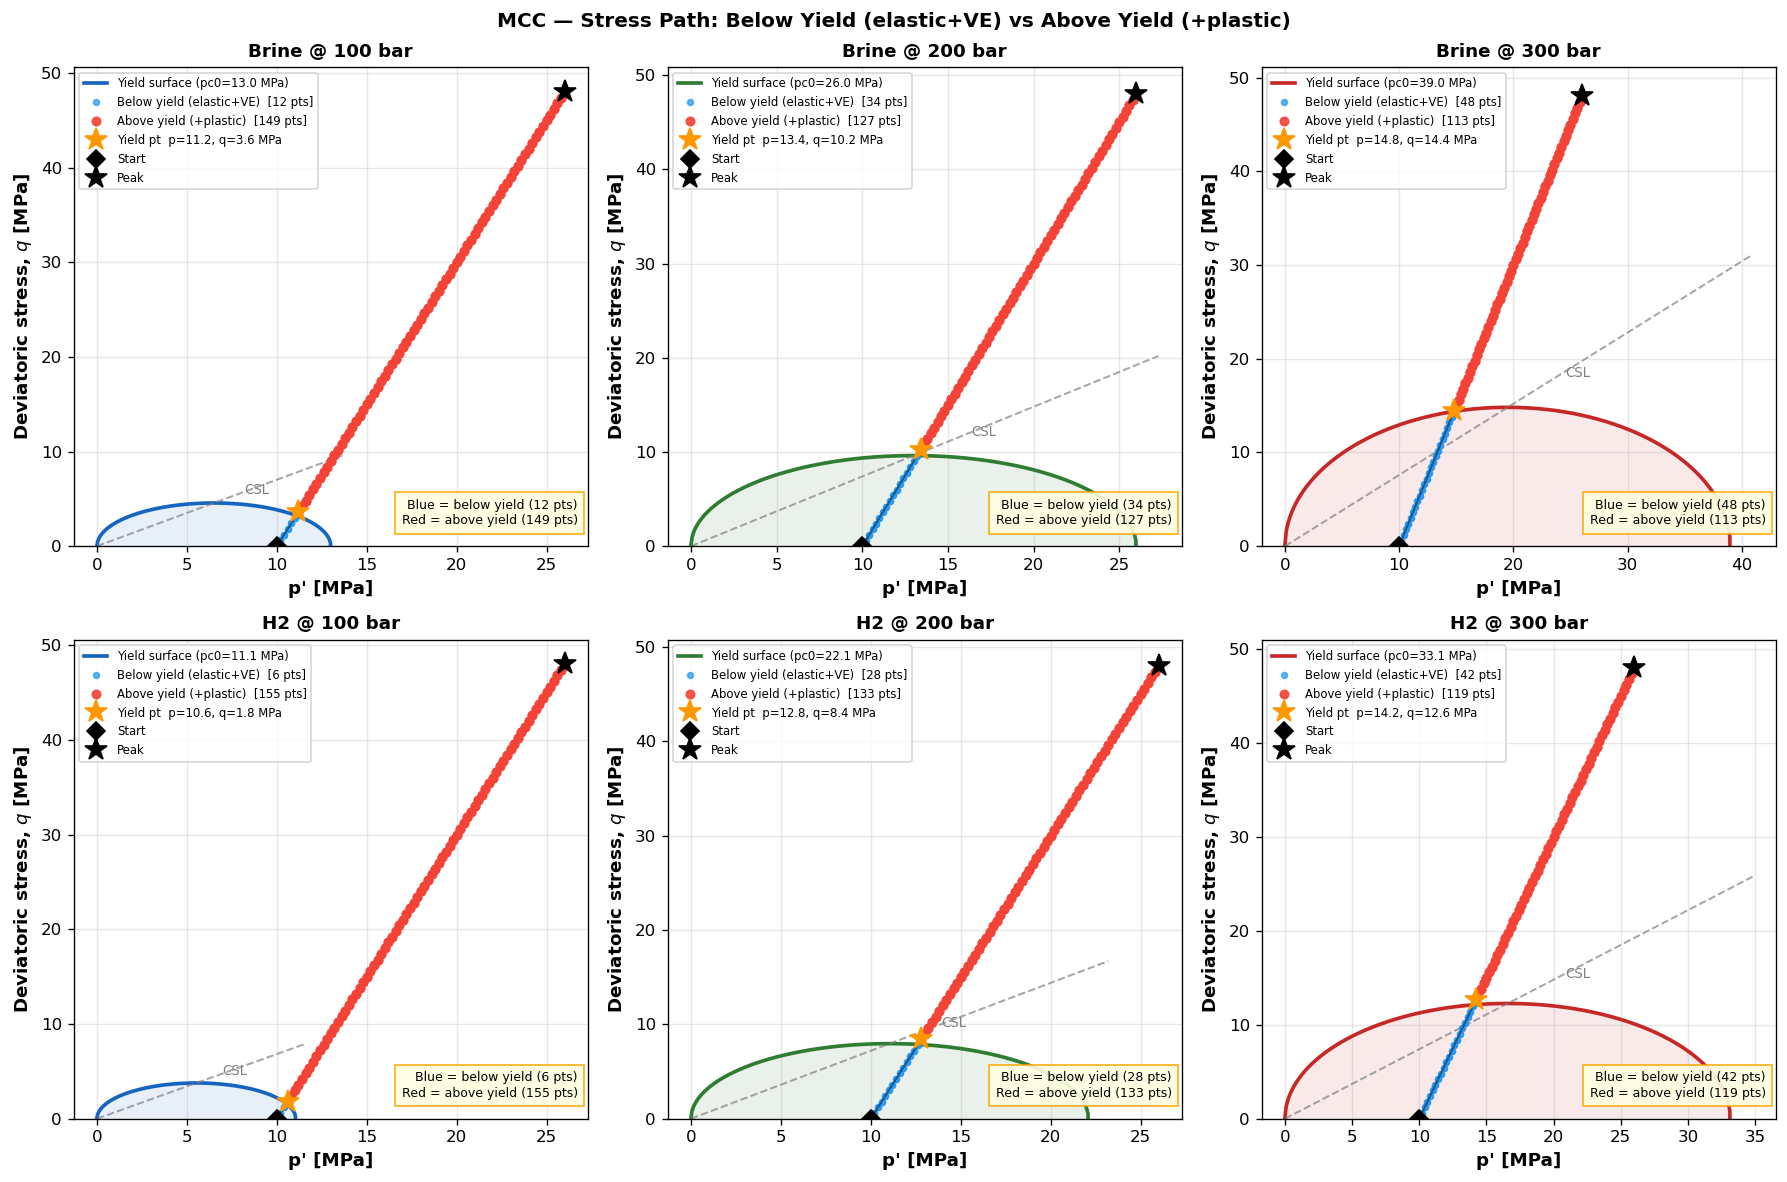

Fig 01 saved (stress path below/above yield) OK


In [8]:
# =============================================================================
# CELL 08 — FIGURE 01: STRESS PATH BELOW / ABOVE YIELD
# =============================================================================

CELL_NAME = "Cell08"    # prefix for save_fig — produces Cell08_Fig01_...

fig, axes = plt.subplots(2, 3, figsize=(15, 10))   # 2x3 grid

for row, fluid in enumerate(FLUIDS):
    for col, p_label in enumerate(PRESSURES):
        ax  = axes[row, col]
        g   = table_guess[(fluid, p_label)]   # MCC parameters
        pc0 = g['pc0_MPa'];  M = g['M'];  c = COLOR[p_label]

        # Compute and plot closed MCC yield ellipse
        py, qy = mcc_yield_surface(pc0, M)
        ax.fill(py, qy, alpha=0.10, color=c)
        ax.plot(py, qy, '-', lw=2.2, color=c,
                label=f'Yield surface (pc0={pc0:.1f} MPa)')

        # Critical State Line: q = M * p'
        p_csl = np.array([0, pc0 * 1.05])
        ax.plot(p_csl, M*p_csl, '--', lw=1.2, color='grey', alpha=0.7)
        ax.text(p_csl[-1]*0.6, M*p_csl[-1]*0.58, 'CSL', fontsize=8, color='grey')

        # Yield function along prescribed stress path
        F_path = yield_function(PP_SP, QP_SP, pc0, M)
        below  = F_path <= 0    # below-yield mask
        above  = F_path > 0     # above-yield mask

        # Blue dots: below yield; Red dots: above yield
        ax.plot(PP_SP[below], QP_SP[below], 'o', ms=3.5, color='#2196F3',
                alpha=0.7, label=f'Below yield (elastic+VE)  [{np.sum(below)} pts]')
        ax.plot(PP_SP[above], QP_SP[above], 'o', ms=5.0, color='#F44336',
                alpha=0.9, zorder=5, label=f'Above yield (+plastic)  [{np.sum(above)} pts]')
        ax.plot(PP_SP, QP_SP, 'k-', lw=1.0, alpha=0.4, zorder=3)  # full path line

        # Orange star: first yield crossing point
        cross_idx = np.where(np.diff(above.astype(int)) > 0)[0]
        if len(cross_idx) > 0:
            idx_y = cross_idx[0] + 1
            ax.plot(PP_SP[idx_y], QP_SP[idx_y], '*', ms=14, color='#FF9800',
                    zorder=10, label=f'Yield pt  p={PP_SP[idx_y]:.1f}, q={QP_SP[idx_y]:.1f} MPa')

        ax.plot(Pi, 0, 'kD', ms=8, zorder=8, label='Start')              # start marker
        ax.plot(PP_SP[HALF_SP], QP_SP[HALF_SP], 'k*', ms=14, zorder=8, label='Peak')  # peak

        ax.set_xlabel(PDASH_LABEL);  ax.set_ylabel(Q_LABEL)
        ax.set_title(f'{fluid} @ {p_label}');  ax.set_ylim(bottom=0)
        ax.legend(fontsize=7.0, loc='upper left', ncol=1)

        # Point-count annotation box
        ax.text(0.98, 0.04,
                f'Blue = below yield ({np.sum(below)} pts)\nRed = above yield ({np.sum(above)} pts)',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=7.5,
                bbox=dict(fc='lightyellow', ec='orange', alpha=0.9, pad=4))

fig.suptitle('MCC — Stress Path: Below Yield (elastic+VE) vs Above Yield (+plastic)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('Fig01_StressPath_BelowAboveYield')
plt.show()
print("Fig 01 saved (stress path below/above yield) OK")


## Cell 09 — Figure 02: Strain Decomposition Along Loading Path

### What this cell produces
**Fig 02** — 2×3 stacked-area plots showing elastic (blue), VE (orange), and plastic (red) strain components building up with q along the loading branch.

### Interpretation
- Blue (elastic) grows linearly with q.
- Orange (VE) grows nonlinearly — faster at low q.
- Red (plastic) only appears once F > 0.
- Black dashed vertical line = yield point.

### Saved files
`Cell09_Fig02_StrainDecomposition_Path.pdf / .png`


  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell09_Fig02_StrainDecomposition_Path.pdf
  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell09_Fig02_StrainDecomposition_Path.png


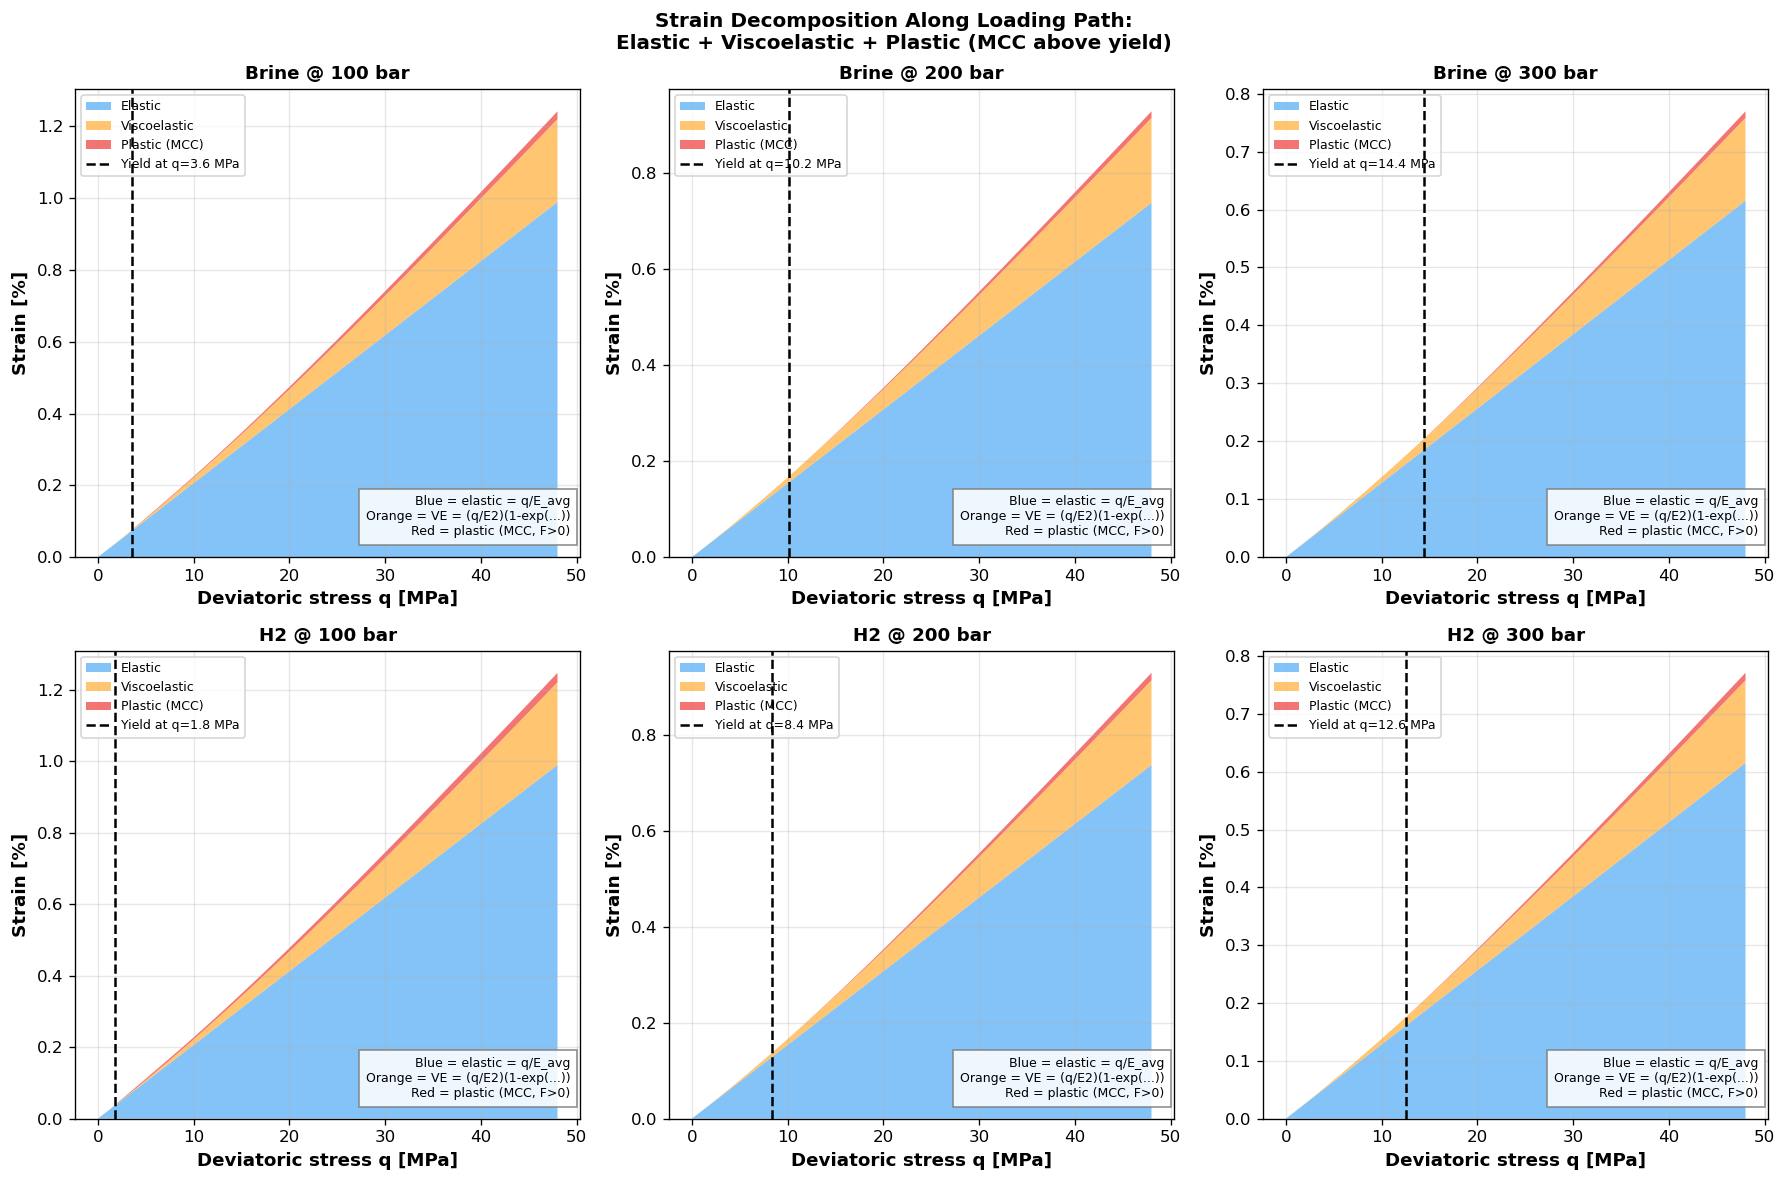

Fig 02 saved (strain decomposition along path) OK


In [9]:
# =============================================================================
# CELL 09 — FIGURE 02: STRAIN DECOMPOSITION ALONG LOADING PATH
# =============================================================================

CELL_NAME = "Cell09"    # prefix for save_fig

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, fluid in enumerate(FLUIDS):
    for col, p_label in enumerate(PRESSURES):
        ax   = axes[row, col]
        g    = table_guess[(fluid, p_label)]
        pc0  = g['pc0_MPa'];  M = g['M'];   c = COLOR[p_label]
        E2   = g['E2_GPa'];   eta1 = g['eta1_GPa_s'];  Eavg = g['Eavg_GPa']
        lam  = g['lam'];      kap  = g['kap']
        e0   = g['phi0'] / (1.0 - g['phi0'])   # void ratio

        pp_load = PP_SP[:HALF_SP + 1]       # loading half of path
        qp_load = QP_SP[:HALF_SP + 1]
        n_pts   = len(pp_load)

        eps_el_path = eps_el_func(qp_load, Eavg)                        # elastic strain
        t_cumul     = np.arange(n_pts) * DT_LOAD                        # cumulative time
        eps_ve_path = eps_ve_func(qp_load, E2, eta1, t_cumul)           # VE strain

        F_path   = yield_function(pp_load, qp_load, pc0, M)
        above_ld = F_path > 0               # above-yield mask on loading branch

        # Simple plastic proxy — accumulates only where F>0
        eps_pl_path = np.zeros(n_pts)
        for i in range(1, n_pts):
            if above_ld[i]:
                pe   = max(pp_load[i], 1e-6)
                eta_ = qp_load[i] / pe
                Om   = (lam-kap) / ((1.0+e0)*pe*(M**2+eta_**2))
                dpp_ = Om * (M**2 - eta_**2) * 0.2
                eps_pl_path[i] = eps_pl_path[i-1] + abs(dpp_)/3.0
            else:
                eps_pl_path[i] = eps_pl_path[i-1]   # no plastic below yield

        # Stacked area: elastic | VE | plastic
        ax.stackplot(qp_load,
                     eps_el_path*100, eps_ve_path*100, eps_pl_path*100,
                     labels=['Elastic','Viscoelastic','Plastic (MCC)'],
                     colors=['#64B5F6','#FFB74D','#EF5350'], alpha=0.80)

        # Mark yield point with vertical dashed line
        if np.any(above_ld):
            idx_y = np.where(above_ld)[0][0]
            ax.axvline(qp_load[idx_y], color='k', lw=1.5, ls='--',
                       label=f'Yield at q={qp_load[idx_y]:.1f} MPa', zorder=6)

        ax.set_xlabel('Deviatoric stress q [MPa]');  ax.set_ylabel('Strain [%]')
        ax.set_title(f'{fluid} @ {p_label}')
        ax.legend(fontsize=7.5, loc='upper left')
        ax.text(0.98, 0.04,
                'Blue = elastic = q/E_avg\nOrange = VE = (q/E2)(1-exp(...))\nRed = plastic (MCC, F>0)',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=7.5,
                bbox=dict(fc='white', ec='grey', alpha=0.88, pad=4))

fig.suptitle('Strain Decomposition Along Loading Path:\nElastic + Viscoelastic + Plastic (MCC above yield)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('Fig02_StrainDecomposition_Path')
plt.show()
print("Fig 02 saved (strain decomposition along path) OK")


## Cell 10 — Figure 03: Yield Function F Along Stress Path

### What this cell produces
**Fig 03** — 2×3 plots of the yield function value F at each stress-path point.
- 🔵 Blue fill = F ≤ 0 (elastic+VE zone)
- 🔴 Red fill  = F > 0 (plastic zone)

### Interpretation
- F dips back below zero during unloading → elastic unloading confirmed.
- The dotted line = first yield crossing index; dash-dot = peak.

### Saved files
`Cell10_Fig03_YieldFunction_Path.pdf / .png`


  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell10_Fig03_YieldFunction_Path.pdf
  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell10_Fig03_YieldFunction_Path.png


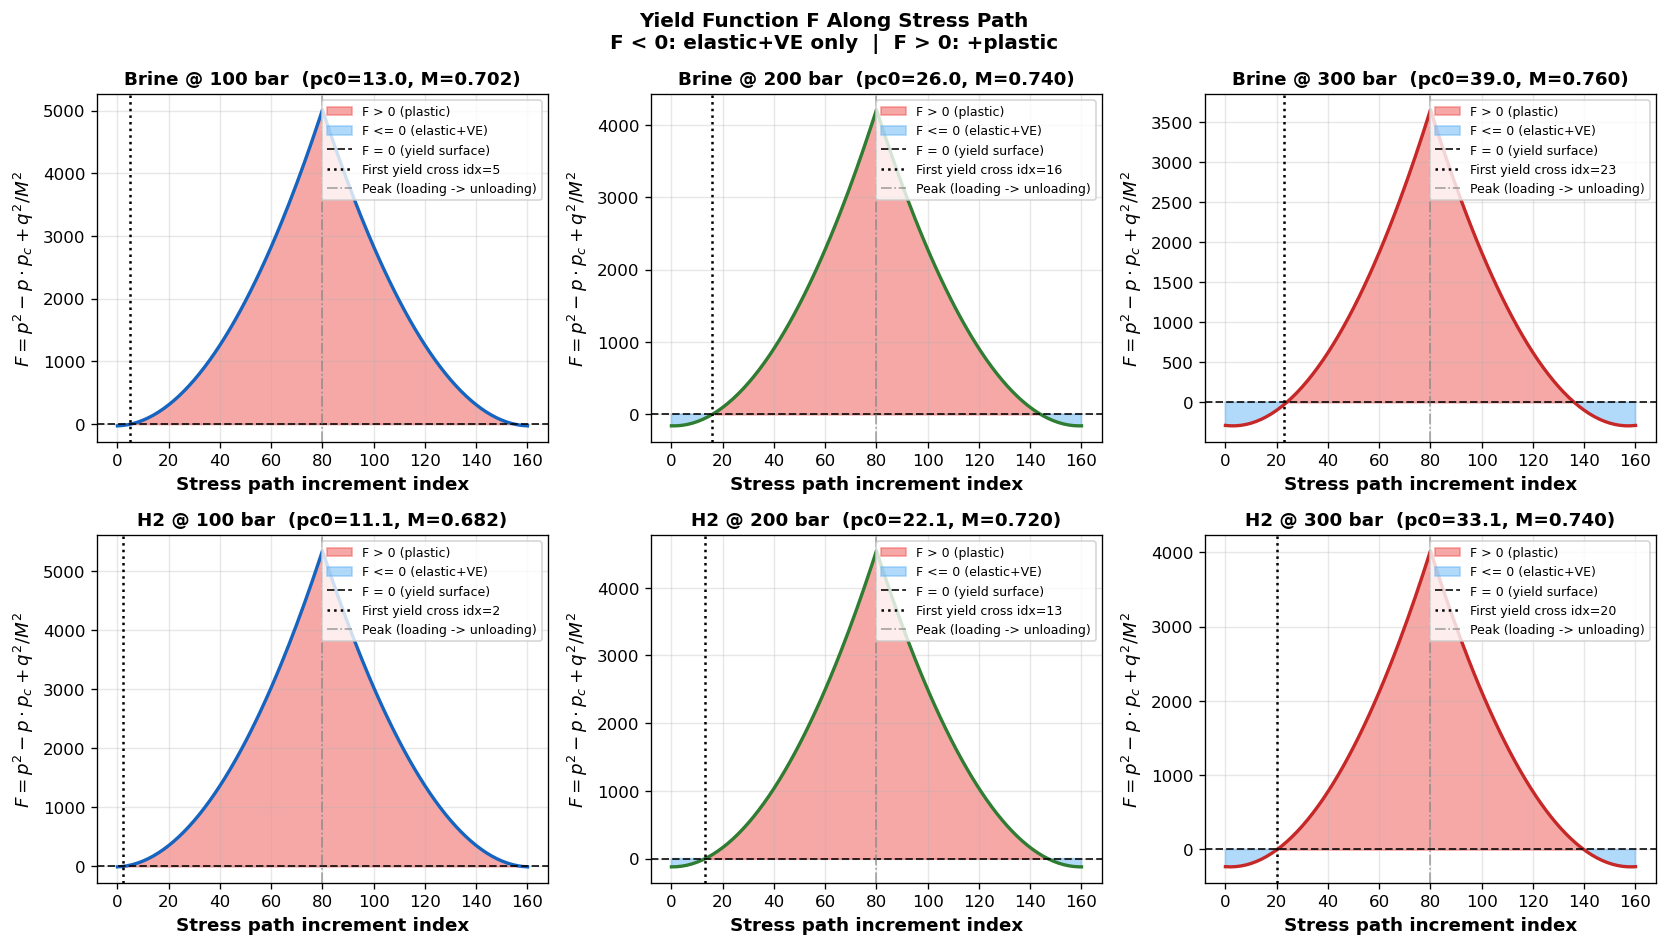

Fig 03 saved (yield function F along path) OK


In [10]:
# =============================================================================
# CELL 10 — FIGURE 03: YIELD FUNCTION F ALONG STRESS PATH
# =============================================================================

CELL_NAME = "Cell10"    # prefix for save_fig

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
path_idx  = np.arange(len(PP_SP))    # x-axis: increment index

for row, fluid in enumerate(FLUIDS):
    for col, p_label in enumerate(PRESSURES):
        ax  = axes[row, col]
        g   = table_guess[(fluid, p_label)]
        pc0 = g['pc0_MPa'];  M = g['M'];  c = COLOR[p_label]

        F_vals = yield_function(PP_SP, QP_SP, pc0, M)   # F at every path point

        # Red fill: F > 0 (plastic zone)
        ax.fill_between(path_idx, F_vals, 0, where=(F_vals > 0),
                        color='#EF5350', alpha=0.5, label='F > 0 (plastic)')
        # Blue fill: F <= 0 (elastic+VE zone)
        ax.fill_between(path_idx, F_vals, 0, where=(F_vals <= 0),
                        color='#64B5F6', alpha=0.5, label='F <= 0 (elastic+VE)')

        ax.plot(path_idx, F_vals, '-', lw=2.0, color=c)     # F curve
        ax.axhline(0, color='k', lw=1.2, ls='--', alpha=0.8,
                   label='F = 0 (yield surface)')            # yield surface reference

        # First plastic crossing vertical line
        cross = np.where(np.diff((F_vals > 0).astype(int)) > 0)[0]
        if len(cross) > 0:
            ax.axvline(cross[0], color='k', lw=1.5, ls=':',
                       label=f'First yield cross idx={cross[0]}')

        # Peak turning-point vertical line
        ax.axvline(HALF_SP, color='grey', lw=1.0, ls='-.', alpha=0.7,
                   label='Peak (loading -> unloading)')

        ax.set_xlabel('Stress path increment index')
        ax.set_ylabel(r'$F = p^2 - p \cdot p_c + q^2/M^2$')
        ax.set_title(f'{fluid} @ {p_label}  (pc0={pc0:.1f}, M={M:.3f})')
        ax.legend(fontsize=7.5, loc='upper right')

fig.suptitle('Yield Function F Along Stress Path\nF < 0: elastic+VE only  |  F > 0: +plastic',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('Fig03_YieldFunction_Path')
plt.show()
print("Fig 03 saved (yield function F along path) OK")


## Cell 11 — Figure 04: 8-Cycle Stress–Strain Loops — All Cases

### What this cell produces
**Fig 04** — 2×3 grid, all 8 cycles per panel coloured by cycle number (plasma: purple→yellow).

### Interpretation
- Rightward shift = ratcheting (permanent strain accumulation).
- Flatter loops in later cycles = hardening (p_c expands).
- Dashed horizontal line = maximum q on initial yield surface.

### Saved files
`Cell11_Fig04_CyclicLoops_AllCases.pdf / .png`


  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell11_Fig04_CyclicLoops_AllCases.pdf
  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell11_Fig04_CyclicLoops_AllCases.png


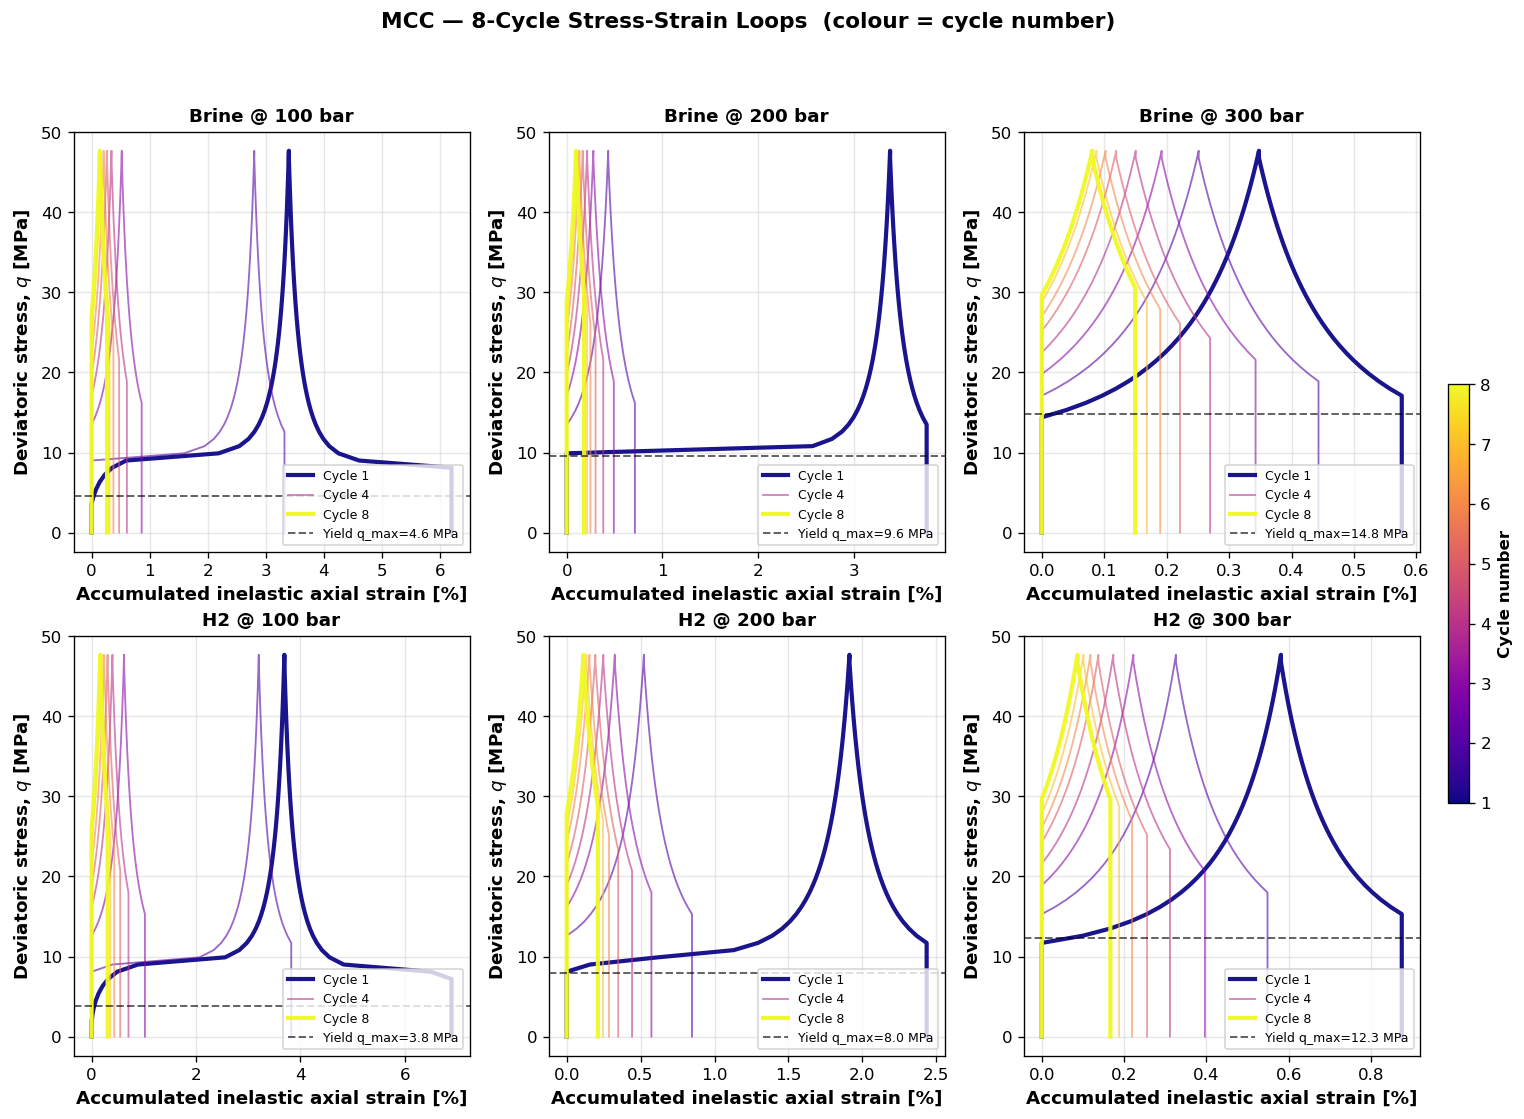

Fig 04 saved (8-cycle loops all cases) OK


In [11]:
# =============================================================================
# CELL 11 — FIGURE 04: 8-CYCLE STRESS-STRAIN LOOPS — ALL CASES
# =============================================================================

CELL_NAME = "Cell11"    # prefix for save_fig

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, fluid in enumerate(FLUIDS):
    for col, p_label in enumerate(PRESSURES):
        ax  = axes[row, col]
        sim = SIM_C[(fluid, p_label)]

        for j, (eps_j, q_j) in enumerate(sim['loops']):
            cc_  = cmap_cyc(j / (NCYC - 1))              # color from plasma map
            lw_  = 2.5  if j in [0, NCYC-1] else 1.1     # thick for C1 and C8
            al_  = 0.95 if j in [0, NCYC-1] else 0.60    # opaque for C1 and C8
            lbl  = f'Cycle {j+1}' if j in [0, 3, 7] else ''  # label C1, C4, C8
            ax.plot(eps_j*100, q_j[:len(eps_j)], color=cc_, lw=lw_, alpha=al_, label=lbl)

        # Max q on initial yield surface
        g   = table_guess[(fluid, p_label)]
        q_y = g['M'] * np.sqrt(g['pc0_MPa']**2 / 4.0)
        ax.axhline(q_y, color='k', lw=1.2, ls='--', alpha=0.6,
                   label=f'Yield q_max={q_y:.1f} MPa')

        ax.set_xlabel(EPS_LABEL);  ax.set_ylabel(Q_LABEL)
        ax.set_title(f'{fluid} @ {p_label}')
        ax.legend(fontsize=7.5, loc='lower right')

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap=cmap_cyc, norm=plt.Normalize(1, NCYC))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.015, pad=0.02)
cbar.set_label('Cycle number', fontsize=10)

fig.suptitle('MCC — 8-Cycle Stress-Strain Loops  (colour = cycle number)',
             fontsize=13, fontweight='bold')
save_fig('Fig04_CyclicLoops_AllCases')
plt.show()
print("Fig 04 saved (8-cycle loops all cases) OK")


## Cell 12 — Figure 05: 8-Cycle Loops — Brine vs H₂ Together

### What this cell produces
**Fig 05** — 1×3 panels, one per pressure, comparing Brine (solid) vs H₂ (dashed) loops for all 8 cycles.

### Saved files
`Cell12_Fig05_CyclicLoops_BrineH2.pdf / .png`


  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell12_Fig05_CyclicLoops_BrineH2.pdf
  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell12_Fig05_CyclicLoops_BrineH2.png


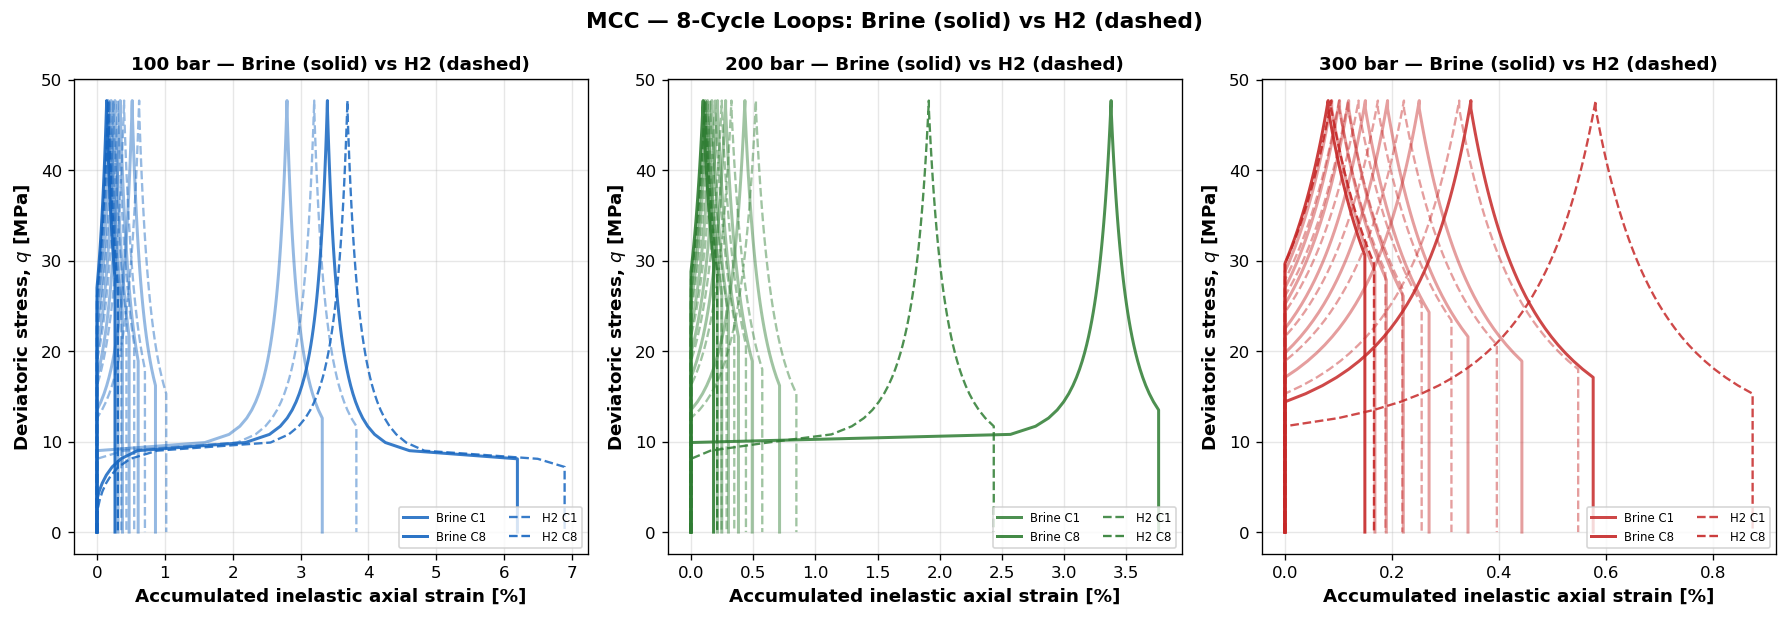

Fig 05 saved (8-cycle loops Brine vs H2) OK


In [12]:
# =============================================================================
# CELL 12 — FIGURE 05: 8-CYCLE LOOPS — BRINE vs H2 TOGETHER
# =============================================================================

CELL_NAME = "Cell12"    # prefix for save_fig

fig, axes = plt.subplots(1, 3, figsize=(15, 5.2))

for col, p_label in enumerate(PRESSURES):
    ax = axes[col];  c = COLOR[p_label]

    for fluid in FLUIDS:
        sim = SIM_C[(fluid, p_label)]
        ls  = '-'  if fluid=='Brine' else '--'   # solid=Brine, dashed=H2
        lw_ = 1.8  if fluid=='Brine' else 1.4

        for j, (eps_j, q_j) in enumerate(sim['loops']):
            al_  = 0.85 if j==0 else (0.90 if j==NCYC-1 else 0.45)  # highlight first/last
            lbl  = f'{fluid} C{j+1}' if j in [0, NCYC-1] else ''
            ax.plot(eps_j*100, q_j[:len(eps_j)], ls, lw=lw_, color=c, alpha=al_, label=lbl)

    ax.set_xlabel(EPS_LABEL);  ax.set_ylabel(Q_LABEL)
    ax.set_title(f'{p_label} — Brine (solid) vs H2 (dashed)')
    ax.legend(fontsize=7, loc='lower right', ncol=2)

fig.suptitle('MCC — 8-Cycle Loops: Brine (solid) vs H2 (dashed)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('Fig05_CyclicLoops_BrineH2')
plt.show()
print("Fig 05 saved (8-cycle loops Brine vs H2) OK")


## Cell 13 — Figure 06: p_c Hardening Over 8 Cycles

### What this cell produces
**Fig 06** — 1×2 panels (Brine | H₂): preconsolidation pressure p_c vs cycle number.

### Hardening law
$$p_c^{j+1} = p_c^j \exp\!\left(\frac{1+e}{\lambda-\kappa}\,d\varepsilon_v^p\right)$$

### Saved files
`Cell13_Fig06_PcHardening_Cycles.pdf / .png`


  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell13_Fig06_PcHardening_Cycles.pdf
  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell13_Fig06_PcHardening_Cycles.png


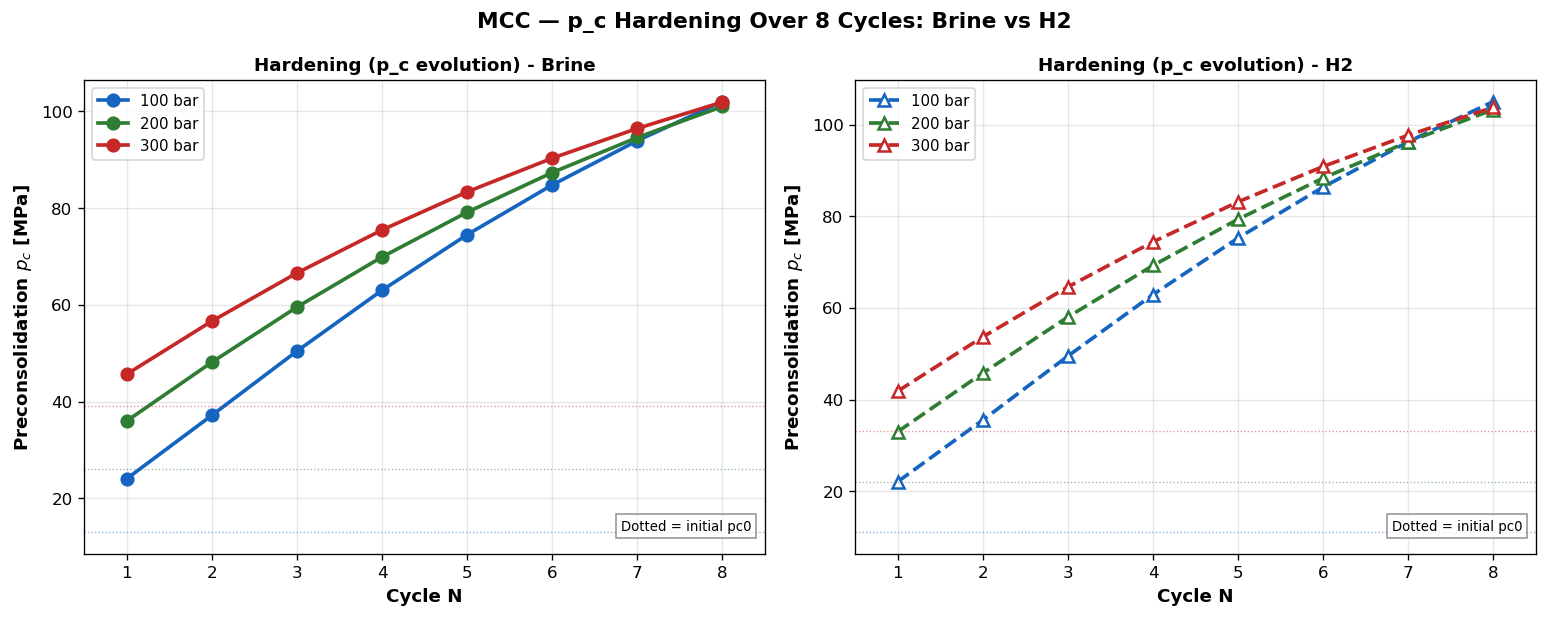

Fig 06 saved (pc hardening over cycles) OK


In [13]:
# =============================================================================
# CELL 13 — FIGURE 06: p_c HARDENING OVER 8 CYCLES
# =============================================================================

CELL_NAME = "Cell13"    # prefix for save_fig

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

for ax, fluid in zip(axes, FLUIDS):
    for p_label in PRESSURES:
        sim = SIM_C[(fluid, p_label)];  c = COLOR[p_label]
        ls  = '-'  if fluid=='Brine' else '--'
        mk  = 'o'  if fluid=='Brine' else '^'
        mfc = c    if fluid=='Brine' else 'white'   # filled=Brine, open=H2

        ax.plot(CYC_ARR, sim['pc_cyc'], ls+mk, lw=2.2, ms=7,
                color=c, mfc=mfc, mew=1.5, label=p_label)    # pc evolution
        ax.axhline(sim['pc0'], color=c, lw=0.8, ls=':', alpha=0.5)  # initial pc0

    ax.set_xlabel('Cycle N');  ax.set_ylabel(PC_LABEL)
    ax.set_title(f'Hardening (p_c evolution) - {fluid}')
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.set_xlim(0.5, 8.5);  ax.legend(fontsize=9)
    ax.text(0.98, 0.05, 'Dotted = initial pc0',
            transform=ax.transAxes, ha='right', fontsize=8,
            bbox=dict(fc='white', ec='grey', alpha=0.8, pad=3))

fig.suptitle('MCC — p_c Hardening Over 8 Cycles: Brine vs H2',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('Fig06_PcHardening_Cycles')
plt.show()
print("Fig 06 saved (pc hardening over cycles) OK")


## Cell 14 — Figure 07: Below Yield — Elastic + VE vs q

### What this cell produces
**Fig 07** — 2×3 stacked-fill plots of elastic (blue) and VE (orange) strain vs q in the below-yield zone at t = 3600 s.

### Interpretation
- No plastic strain below yield (F < 0).
- VE adds on top of elastic; total grows nonlinearly.
- Dashed vertical line = maximum sub-yield q (yield point).

### Saved files
`Cell14_Fig07_BelowYield_ElasticVE.pdf / .png`


  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell14_Fig07_BelowYield_ElasticVE.pdf
  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell14_Fig07_BelowYield_ElasticVE.png


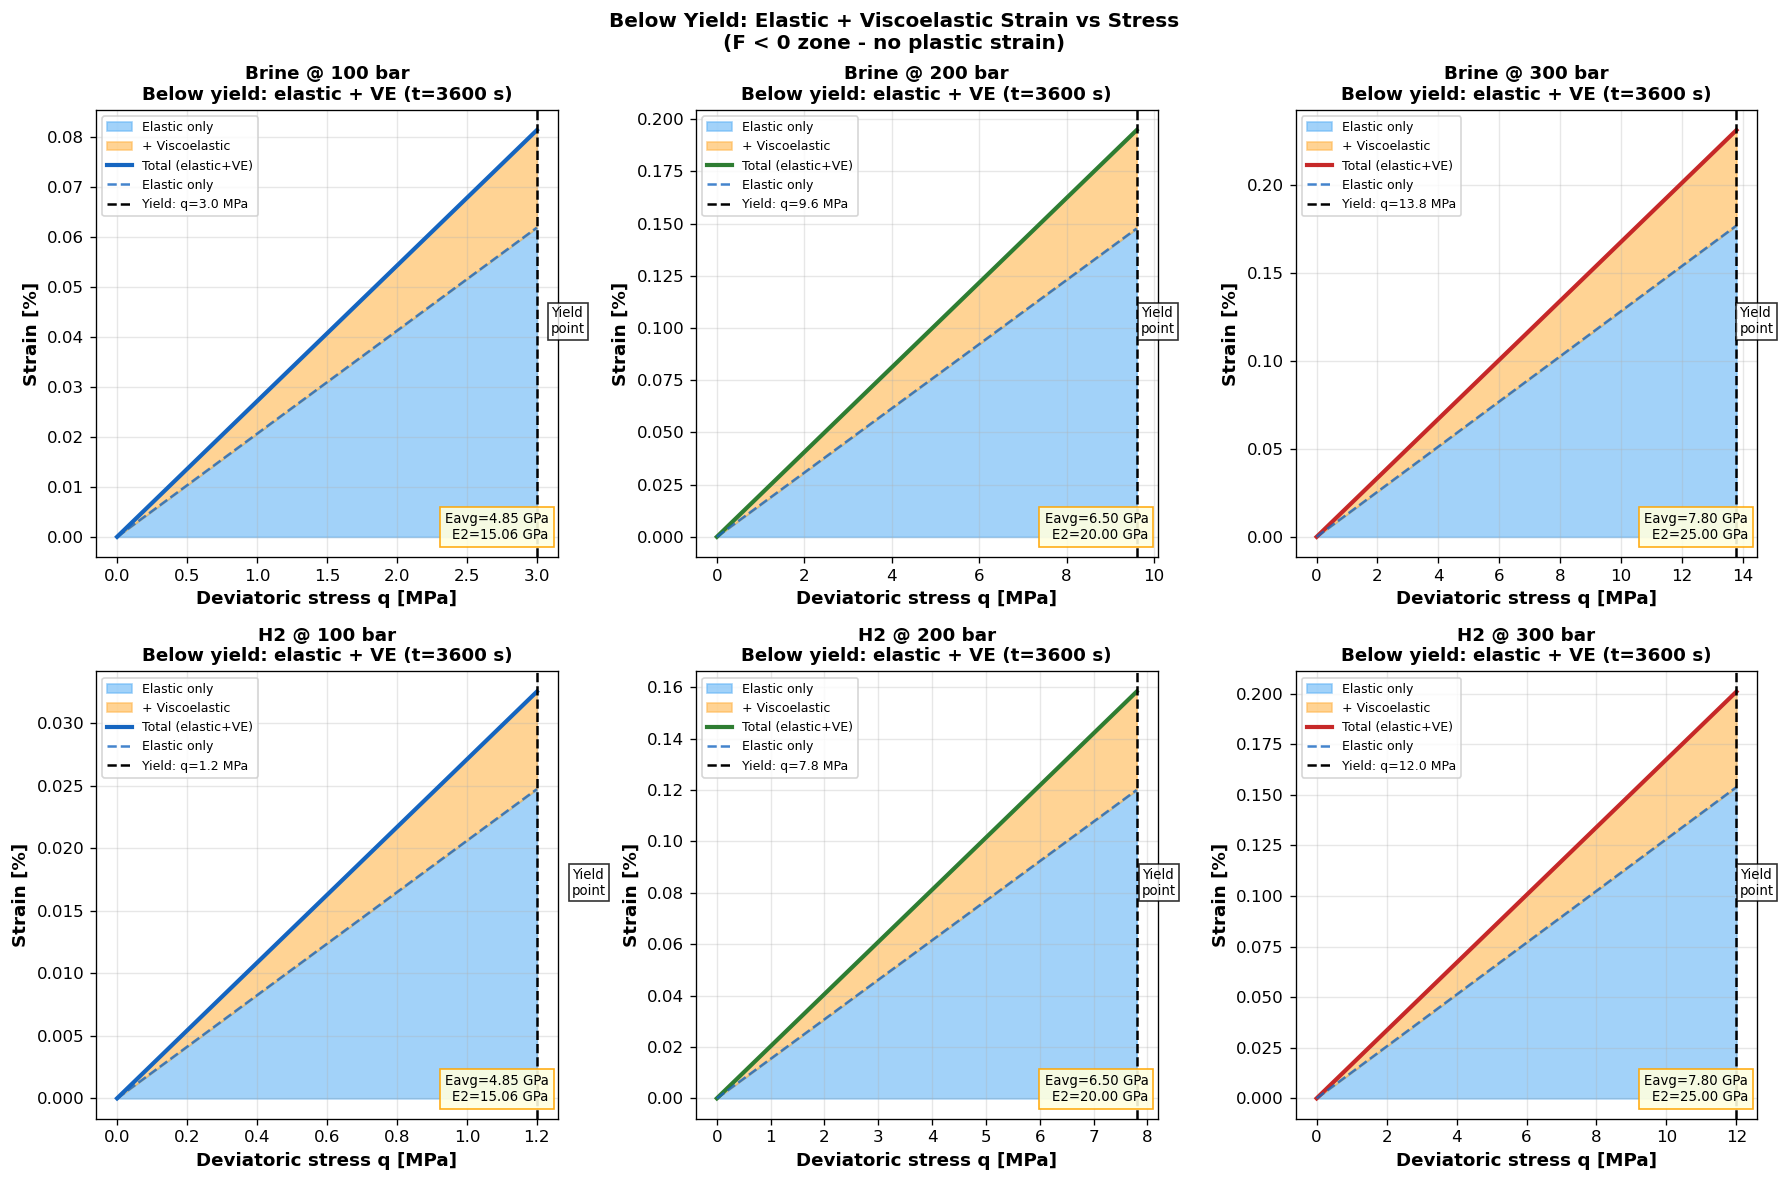

Fig 07 saved (below yield elastic+VE vs q) OK


In [14]:
# =============================================================================
# CELL 14 — FIGURE 07: BELOW YIELD — ELASTIC + VE vs q
# =============================================================================

CELL_NAME = "Cell14"    # prefix for save_fig

t_one = 3600.0    # representative loading time for VE evaluation [s]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, fluid in enumerate(FLUIDS):
    for col, p_label in enumerate(PRESSURES):
        ax   = axes[row, col]
        g    = table_guess[(fluid, p_label)]
        pc0_ = g['pc0_MPa'];  M_ = g['M'];  c = COLOR[p_label]
        E2_  = g['E2_GPa'];   eta1_ = g['eta1_GPa_s'];  Eavg_ = g['Eavg_GPa']

        # Maximum sub-yield q
        F_vals = yield_function(PP_SP, QP_SP, pc0_, M_)
        below_ = F_vals <= 0
        q_max_elastic = QP_SP[below_].max() if np.any(below_) else 5.0

        q_range = np.linspace(0, q_max_elastic, 300)   # q sweep below yield

        eps_el_range    = eps_el_func(q_range, Eavg_)                  # elastic
        eps_ve_atQ      = eps_ve_func(q_range, E2_, eta1_, t_one)     # VE at t_one
        eps_total_below = eps_el_range + eps_ve_atQ                    # total

        # Stacked fill: elastic | VE
        ax.fill_between(q_range, 0, eps_el_range*100,
                        alpha=0.6, color='#64B5F6', label='Elastic only')
        ax.fill_between(q_range, eps_el_range*100, eps_total_below*100,
                        alpha=0.6, color='#FFB74D', label='+ Viscoelastic')
        ax.plot(q_range, eps_total_below*100, '-', lw=2.5, color=c,
                label='Total (elastic+VE)')
        ax.plot(q_range, eps_el_range*100, '--', lw=1.5, color='#1565C0',
                alpha=0.8, label='Elastic only')

        # Yield point marker
        ax.axvline(q_max_elastic, color='k', lw=1.5, ls='--',
                   label=f'Yield: q={q_max_elastic:.1f} MPa')
        ax.text(q_max_elastic+0.1, eps_total_below[-1]*100*0.5,
                'Yield\npoint', fontsize=8, color='k',
                bbox=dict(fc='white', ec='k', alpha=0.8, pad=2))

        ax.set_xlabel('Deviatoric stress q [MPa]');  ax.set_ylabel('Strain [%]')
        ax.set_title(f'{fluid} @ {p_label}\nBelow yield: elastic + VE (t=3600 s)')
        ax.legend(fontsize=7.5, loc='upper left')
        ax.text(0.98, 0.04, f'Eavg={Eavg_:.2f} GPa\nE2={E2_:.2f} GPa',
                transform=ax.transAxes, ha='right', fontsize=8,
                bbox=dict(fc='lightyellow', ec='orange', alpha=0.9, pad=3))

fig.suptitle('Below Yield: Elastic + Viscoelastic Strain vs Stress\n(F < 0 zone - no plastic strain)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('Fig07_BelowYield_ElasticVE')
plt.show()
print("Fig 07 saved (below yield elastic+VE vs q) OK")


## Cell 15 — Figure 08: VE Creep Build-Up vs Time (Below Yield)

### What this cell produces
**Fig 08** — 1×2 panels: VE creep strain vs time at constant sub-yield stress (q = 80% of q_yield_max).

### Kelvin–Voigt creep
$$\varepsilon^{ve}(t) = \frac{q}{E_2}\left(1-e^{-t/\tau}\right), \quad \tau=\eta_1/E_2$$

### Saved files
`Cell15_Fig08_BelowYield_VECreep_Time.pdf / .png`


  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell15_Fig08_BelowYield_VECreep_Time.pdf
  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell15_Fig08_BelowYield_VECreep_Time.png


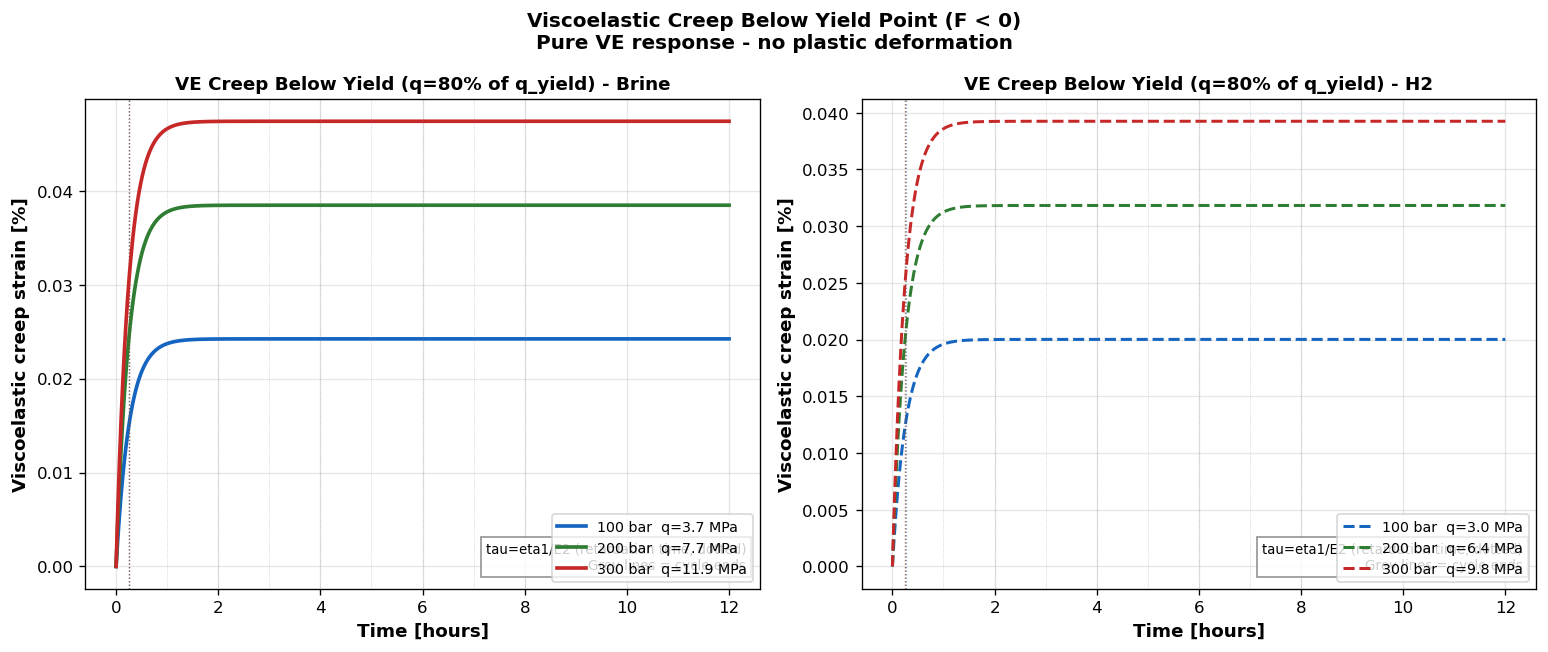

Fig 08 saved (VE creep below yield vs time) OK


In [15]:
# =============================================================================
# CELL 15 — FIGURE 08: VE CREEP BUILD-UP vs TIME (BELOW YIELD)
# =============================================================================

CELL_NAME = "Cell15"    # prefix for save_fig

t_arr_long = np.linspace(0, NCYC * 3600.0 * 1.5, 1500)   # time array [s]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, fluid in zip(axes, FLUIDS):
    for p_label in PRESSURES:
        g     = table_guess[(fluid, p_label)]
        pc0_  = g['pc0_MPa'];  M_  = g['M'];  c = COLOR[p_label]
        E2_   = g['E2_GPa'];   eta1_ = g['eta1_GPa_s']

        q_sub = 0.80 * M_ * np.sqrt(pc0_**2 / 4.0)    # sub-yield stress [MPa]
        eve_  = eps_ve_func(q_sub, E2_, eta1_, t_arr_long)  # VE creep curve
        tau_  = eta1_ / E2_                             # retardation time [s]

        ls  = '-'  if fluid=='Brine' else '--'
        lw_ = 2.2  if fluid=='Brine' else 1.8

        ax.plot(t_arr_long/3600, eve_*100, ls, lw=lw_, color=c,
                label=f'{p_label}  q={q_sub:.1f} MPa')
        ax.axvline(tau_/3600, color=c, lw=0.8, ls=':', alpha=0.5)  # tau marker

    for nc in range(1, NCYC+1):    # grey lines at cycle ends
        ax.axvline(nc, color='grey', lw=0.5, ls=':', alpha=0.4)

    ax.set_xlabel('Time [hours]');  ax.set_ylabel('Viscoelastic creep strain [%]')
    ax.set_title(f'VE Creep Below Yield (q=80% of q_yield) - {fluid}')
    ax.legend(fontsize=8.5, loc='lower right')
    ax.text(0.98, 0.04, 'tau=eta1/E2 (retardation time, dotted)\nGrey lines = cycle ends',
            transform=ax.transAxes, ha='right', fontsize=8,
            bbox=dict(fc='white', ec='grey', alpha=0.85, pad=3))

fig.suptitle('Viscoelastic Creep Below Yield Point (F < 0)\nPure VE response - no plastic deformation',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('Fig08_BelowYield_VECreep_Time')
plt.show()
print("Fig 08 saved (VE creep below yield vs time) OK")


## Cell 16 — Figure 09: Elastic vs VE at Different Load Durations

### What this cell produces
**Fig 09** — 1×2 grouped bar charts: total below-yield strain (elastic+VE) at 4 durations: 15 s, 600 s, 3600 s, 8 h.

### Interpretation
- Elastic bar is time-independent.
- VE grows with loading duration as dashpot relaxes.
- At 8 h the VE approaches its asymptote q/E₂.

### Saved files
`Cell16_Fig09_BelowYield_ElasticVE_Duration.pdf / .png`


  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell16_Fig09_BelowYield_ElasticVE_Duration.pdf
  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell16_Fig09_BelowYield_ElasticVE_Duration.png


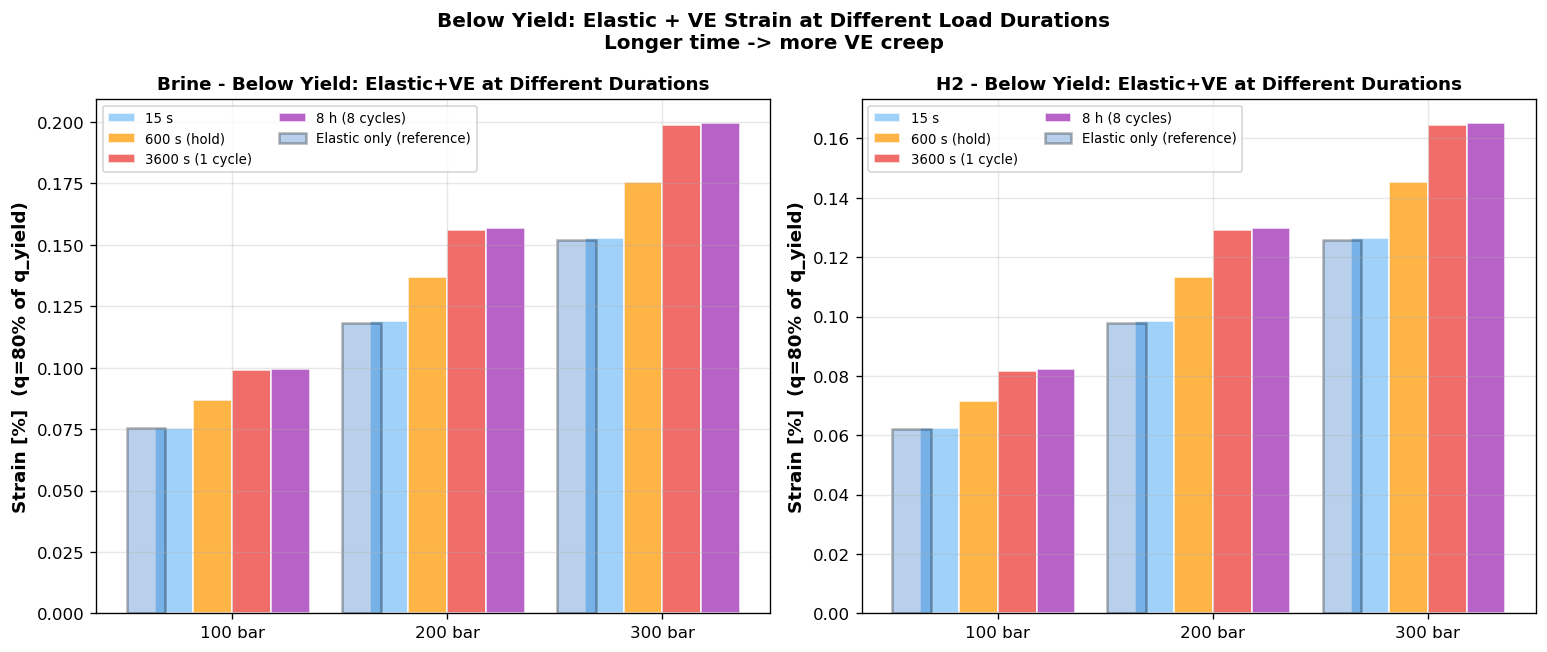

Fig 09 saved (elastic vs VE ratio at different durations) OK


In [16]:
# =============================================================================
# CELL 16 — FIGURE 09: ELASTIC vs VE AT DIFFERENT LOAD DURATIONS
# =============================================================================

CELL_NAME = "Cell16"    # prefix for save_fig

times_compare = [15.0, 600.0, 3600.0, 28800.0]
time_labels   = ['15 s', '600 s (hold)', '3600 s (1 cycle)', '8 h (8 cycles)']
bar_colors    = ['#90CAF9', '#FFA726', '#EF5350', '#AB47BC']

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, fluid in zip(axes, FLUIDS):
    case_names   = []
    elastic_vals = {tl: [] for tl in time_labels}
    ve_vals      = {tl: [] for tl in time_labels}

    for p_label in PRESSURES:
        g     = table_guess[(fluid, p_label)]
        pc0_  = g['pc0_MPa'];  M_   = g['M']
        E2_   = g['E2_GPa'];   eta1_= g['eta1_GPa_s'];  Eavg_ = g['Eavg_GPa']
        q_sub = 0.80 * M_ * np.sqrt(pc0_**2 / 4.0)   # sub-yield stress
        eel_  = eps_el_func(q_sub, Eavg_) * 100       # elastic strain [%]
        case_names.append(p_label)

        for t_, tl in zip(times_compare, time_labels):
            ve_  = eps_ve_func(q_sub, E2_, eta1_, t_) * 100   # VE strain [%]
            elastic_vals[tl].append(eel_);  ve_vals[tl].append(ve_)

    x = np.arange(len(case_names));  w = 0.18

    for k, (tl, bc) in enumerate(zip(time_labels, bar_colors)):
        offset  = (k - 1.5) * w
        bars_el = np.array(elastic_vals[tl])
        bars_ve = np.array(ve_vals[tl])
        ax.bar(x+offset, bars_el+bars_ve, w, bottom=0,
               color=bc, alpha=0.85, edgecolor='white', label=tl)

    # Elastic-only reference bar
    el_ref = [eps_el_func(0.80*table_guess[(fluid,p)]['M']*
                          np.sqrt(table_guess[(fluid,p)]['pc0_MPa']**2/4.0),
                          table_guess[(fluid,p)]['Eavg_GPa'])*100 for p in PRESSURES]
    ax.bar(x-0.4, el_ref, 0.18, color='#1565C0', alpha=0.3, edgecolor='k',
           lw=1.5, label='Elastic only (reference)')

    ax.set_xticks(x);  ax.set_xticklabels(case_names)
    ax.set_ylabel('Strain [%]  (q=80% of q_yield)')
    ax.set_title(f'{fluid} - Below Yield: Elastic+VE at Different Durations')
    ax.legend(fontsize=8, ncol=2)

fig.suptitle('Below Yield: Elastic + VE Strain at Different Load Durations\nLonger time -> more VE creep',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('Fig09_BelowYield_ElasticVE_Duration')
plt.show()
print("Fig 09 saved (elastic vs VE ratio at different durations) OK")


## Cell 17 — Figure 10: Cycle 1 — Below / Above Yield Coloured

### What this cell produces
**Fig 10** — 2×3 scatter overlay on Cycle-1 loop:
- 🔵 Blue scatter = below yield (elastic+VE)
- 🔴 Red scatter  = above yield (+plastic)
- Orange ↔ arrow = VE strain width at yield level

### Saved files
`Cell17_Fig10_BelowAbove_Yield_Cycle1.pdf / .png`


  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell17_Fig10_BelowAbove_Yield_Cycle1.pdf
  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell17_Fig10_BelowAbove_Yield_Cycle1.png


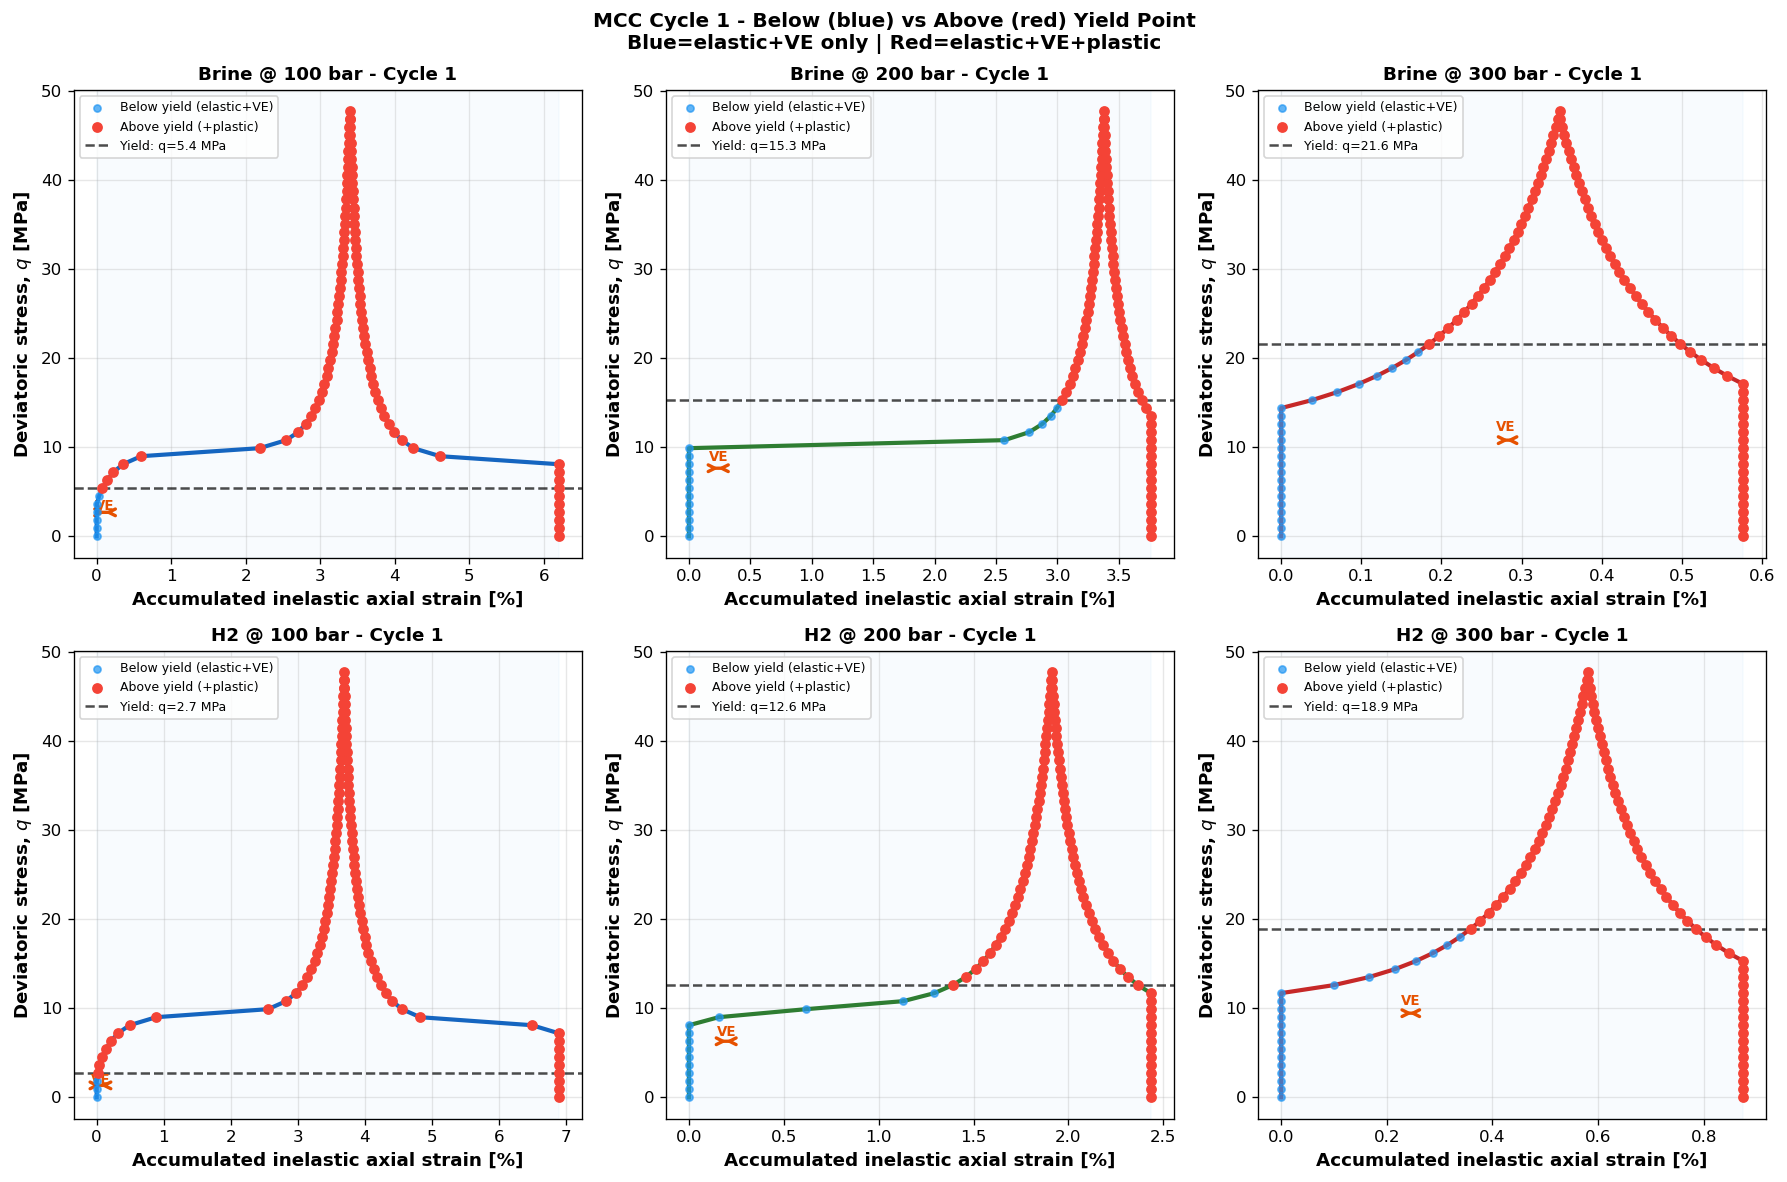

Fig 10 saved (below/above yield cycle 1) OK


In [17]:
# =============================================================================
# CELL 17 — FIGURE 10: CYCLE 1 — BELOW / ABOVE YIELD COLOURED
# =============================================================================

CELL_NAME = "Cell17"    # prefix for save_fig

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, fluid in enumerate(FLUIDS):
    for col, p_label in enumerate(PRESSURES):
        ax   = axes[row, col]
        g    = table_guess[(fluid, p_label)]
        pc0_ = g['pc0_MPa'];  M_ = g['M'];  c = COLOR[p_label]
        E2_  = g['E2_GPa'];   eta1_ = g['eta1_GPa_s'];  Eavg_ = g['Eavg_GPa']

        # Cycle-1 loop arrays
        sim      = SIM_C[(fluid, p_label)]
        eps_c1, q_c1 = sim['loops'][0]

        # Yield function along cycle-1 path
        F_c1     = yield_function(PP_SP[:len(q_c1)], QP_SP[:len(q_c1)], pc0_, M_)
        below_c1 = F_c1 <= 0
        above_c1 = F_c1 > 0

        # Yield crossing q value
        cross_ = np.where(np.diff(above_c1.astype(int)) > 0)[0]
        q_yield_cross = (q_c1[cross_[0]+1] if len(cross_)>0 and cross_[0]+1<len(q_c1)
                         else Q_PEAK)

        ax.axvspan(0, max(eps_c1)*100, alpha=0.03, color='#2196F3')  # background hint
        ax.plot(eps_c1*100, q_c1[:len(eps_c1)], '-', lw=2.5, color=c, zorder=5)  # loop

        # Blue scatter: below yield
        ax.scatter(eps_c1[:len(q_c1)][below_c1[:len(eps_c1)]]*100,
                   q_c1[:len(eps_c1)][below_c1[:len(eps_c1)]],
                   s=18, color='#2196F3', zorder=6, alpha=0.7, label='Below yield (elastic+VE)')
        # Red scatter: above yield
        ax.scatter(eps_c1[:len(q_c1)][above_c1[:len(eps_c1)]]*100,
                   q_c1[:len(eps_c1)][above_c1[:len(eps_c1)]],
                   s=30, color='#F44336', zorder=7, label='Above yield (+plastic)')

        ax.axhline(q_yield_cross, color='k', lw=1.5, ls='--', alpha=0.7,
                   label=f'Yield: q={q_yield_cross:.1f} MPa')

        # VE width arrow at yield level
        eel_ = eps_el_func(q_yield_cross, Eavg_)*100
        eve_ = eps_ve_func(q_yield_cross, E2_, eta1_, DT_LOAD*5)*100
        ax.annotate('', xy=(eel_+eve_, q_yield_cross*0.5), xytext=(eel_, q_yield_cross*0.5),
                    arrowprops=dict(arrowstyle='<->', color='#E65100', lw=2))
        ax.text((eel_+eve_+eel_)/2, q_yield_cross*0.55, 'VE',
                ha='center', fontsize=8, color='#E65100', fontweight='bold')

        ax.set_xlabel(EPS_LABEL);  ax.set_ylabel(Q_LABEL)
        ax.set_title(f'{fluid} @ {p_label} - Cycle 1')
        ax.legend(fontsize=7.5, loc='upper left')

fig.suptitle('MCC Cycle 1 - Below (blue) vs Above (red) Yield Point\nBlue=elastic+VE only | Red=elastic+VE+plastic',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('Fig10_BelowAbove_Yield_Cycle1')
plt.show()
print("Fig 10 saved (below/above yield cycle 1) OK")


## Cell 18 — Figure 11: Strain Components Per Cycle (Stacked Bars)

### What this cell produces
**Fig 11** — 2×3 stacked bar charts: elastic (blue), VE (orange), plastic (red) per cycle.

### Interpretation
- Elastic bar is approximately constant (same peak q each cycle).
- Plastic bar **decreases** each cycle → hardening confirmed.
- VE bar grows slowly as total elapsed time increases.

### Saved files
`Cell18_Fig11_StrainComponents_PerCycle.pdf / .png`


  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell18_Fig11_StrainComponents_PerCycle.pdf
  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell18_Fig11_StrainComponents_PerCycle.png


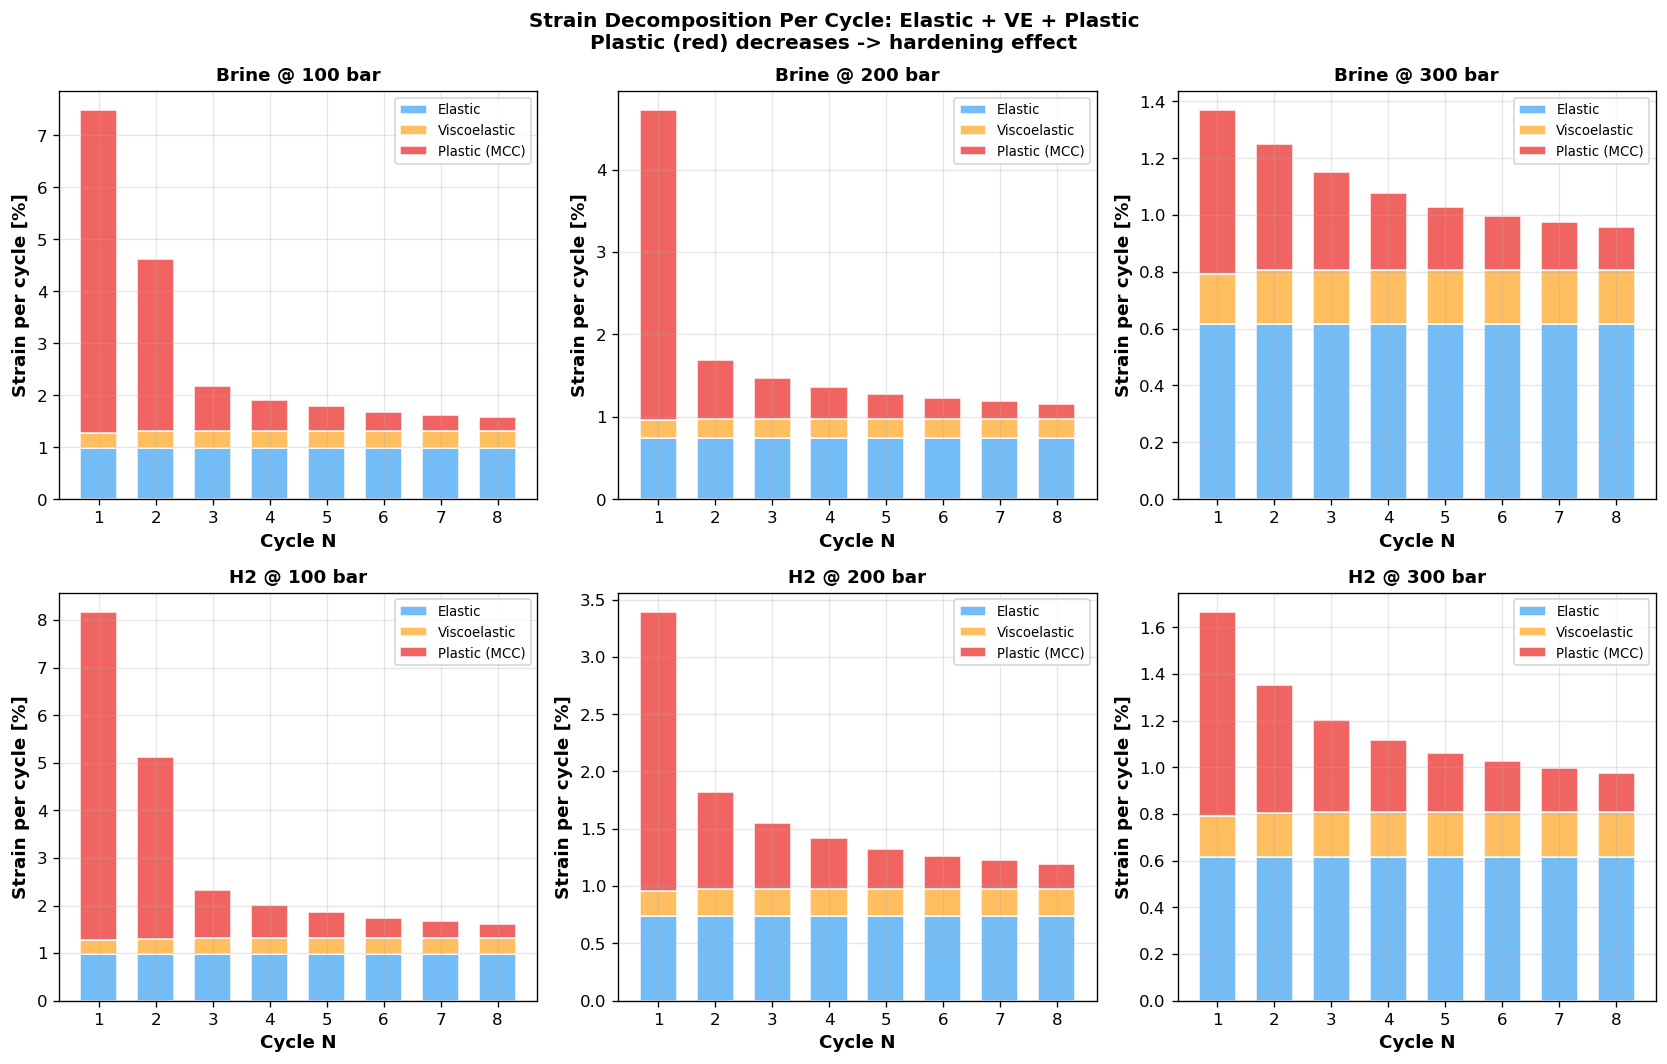

Fig 11 saved (strain components per cycle stacked bars) OK


In [18]:
# =============================================================================
# CELL 18 — FIGURE 11: STRAIN COMPONENTS PER CYCLE (STACKED BARS)
# =============================================================================

CELL_NAME = "Cell18"    # prefix for save_fig

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for row, fluid in enumerate(FLUIDS):
    for col, p_label in enumerate(PRESSURES):
        ax   = axes[row, col]
        g    = table_guess[(fluid, p_label)]
        E2_  = g['E2_GPa'];  eta1_ = g['eta1_GPa_s'];  Eavg_ = g['Eavg_GPa']
        sim  = SIM_C[(fluid, p_label)]

        el_per = np.full(NCYC, eps_el_func(Q_PEAK, Eavg_)*100)  # elastic [%] constant
        ve_per = sim['ve_cyc'] * 100                             # VE [%] per cycle
        pl_per = sim['e_per']  * 100                             # plastic [%] per cycle

        ax.bar(CYC_ARR, el_per, 0.65, label='Elastic',
               color='#64B5F6', alpha=0.90, edgecolor='white')
        ax.bar(CYC_ARR, ve_per, 0.65, bottom=el_per,
               label='Viscoelastic', color='#FFB74D', alpha=0.90, edgecolor='white')
        ax.bar(CYC_ARR, pl_per, 0.65, bottom=el_per+ve_per,
               label='Plastic (MCC)', color='#EF5350', alpha=0.90, edgecolor='white')

        ax.set_xlabel('Cycle N');  ax.set_ylabel('Strain per cycle [%]')
        ax.set_title(f'{fluid} @ {p_label}')
        ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
        ax.set_xlim(0.3, NCYC+0.7);  ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Strain Decomposition Per Cycle: Elastic + VE + Plastic\nPlastic (red) decreases -> hardening effect',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('Fig11_StrainComponents_PerCycle')
plt.show()
print("Fig 11 saved (strain components per cycle stacked bars) OK")


## Cell 19 — Figure 12: VE Recovery — Load → Hold → Unload → Recover

### What this cell produces
**Fig 12** — 1×2 panels: complete VE strain history through all four stages.

| Stage | Colour | Description |
|---|---|---|
| Loading | Blue | KV dashpot relaxes |
| Hold | Orange | Continued slow creep |
| Unloading | Green | Spring drives strain back |
| Recovery | Purple | Exponential decay (τ = η₁/E₂) |

### Key result
All VE strain is **fully recoverable** — no permanent deformation below yield.

### Saved files
`Cell19_Fig12_VE_Recovery.pdf / .png`


  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell19_Fig12_VE_Recovery.pdf
  Saved -> Output_VE_MCCM_YP_Clay_Rich/Cell19_Fig12_VE_Recovery.png


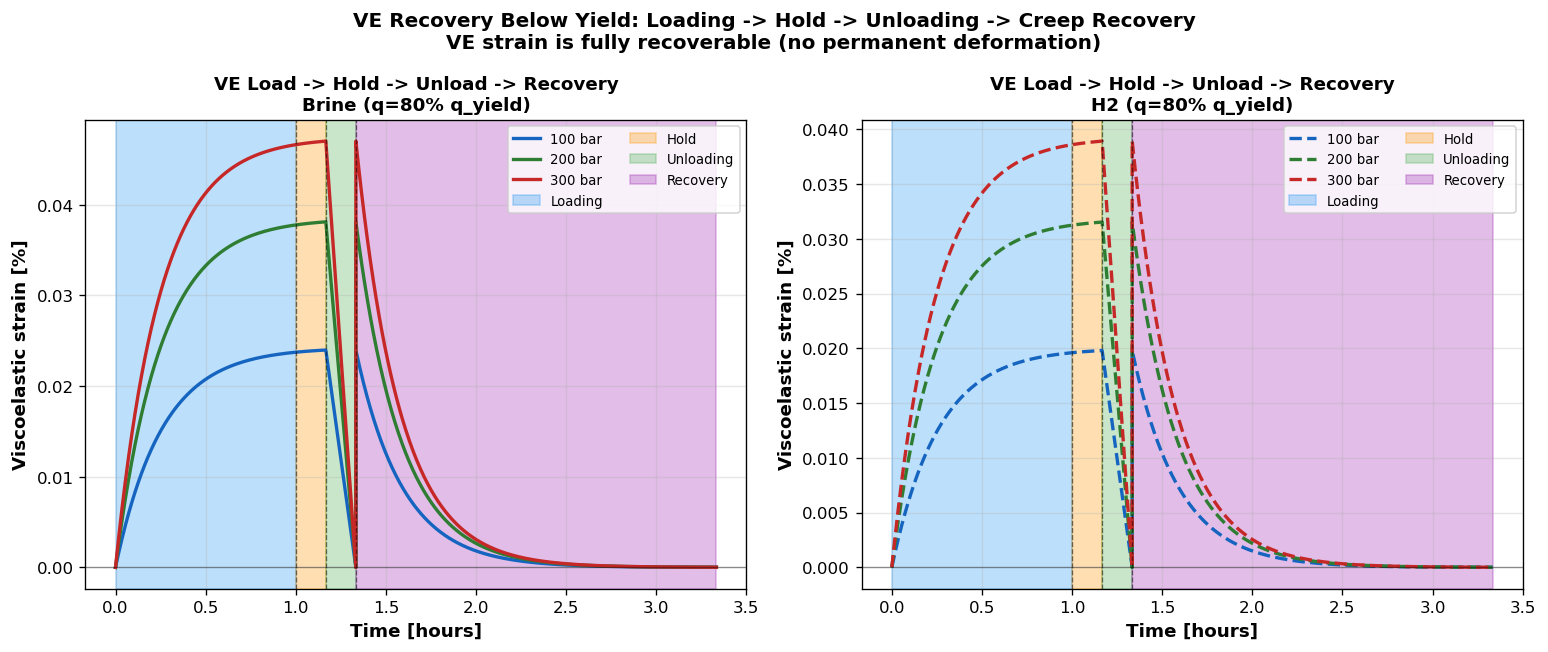

Fig 12 saved (VE recovery after unloading) OK


In [19]:
# =============================================================================
# CELL 19 — FIGURE 12: VE RECOVERY — LOAD -> HOLD -> UNLOAD -> RECOVER
# =============================================================================

CELL_NAME = "Cell19"    # prefix for save_fig

# Time arrays for each stage [s]
t_load   = np.linspace(0,    3600, 500)   # loading: 0 -> 1 h
t_hold   = np.linspace(3600, 4200, 200)   # hold: 1 h -> 1.167 h
t_unload = np.linspace(4200, 4800, 200)   # unloading: 1.167 h -> 1.333 h
t_rec    = np.linspace(4800, 12000, 500)  # recovery: 1.333 h -> ~3.3 h

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, fluid in zip(axes, FLUIDS):
    for p_label in PRESSURES:
        g    = table_guess[(fluid, p_label)]
        pc0_ = g['pc0_MPa'];  M_  = g['M'];  c = COLOR[p_label]
        E2_  = g['E2_GPa'];   eta1_ = g['eta1_GPa_s']
        ls   = '-'  if fluid=='Brine' else '--'
        q_sub = 0.80 * M_ * np.sqrt(pc0_**2 / 4.0)   # sub-yield stress

        # Stage 1 — Loading: KV creep builds up
        eve_load  = eps_ve_func(q_sub, E2_, eta1_, t_load)

        # Stage 2 — Hold: continued slow creep at constant q
        eve_hold  = eps_ve_func(q_sub, E2_, eta1_, t_hold)

        # Stage 3 — Unloading: approximate linear VE return
        t_since_unload = t_unload - 4200.0
        eve_max        = eps_ve_func(q_sub, E2_, eta1_, 4200.0)  # max VE before unload
        eve_unload     = eve_max * (1.0 - t_since_unload / 600.0)

        # Stage 4 — Recovery: exponential decay after full stress removal
        tau_           = eta1_ / E2_                    # retardation time [s]
        t_since_removal= t_rec - 4800.0
        eve_recovery   = eve_max * np.exp(-t_since_removal / tau_)

        # Concatenate all stages and plot
        t_full = np.r_[t_load, t_hold, t_unload, t_rec]
        e_full = np.r_[eve_load, eve_hold, eve_unload, eve_recovery]
        ax.plot(t_full/3600, e_full*100, ls, lw=2.0, color=c, label=p_label)

    # Colour-coded stage background spans
    ax.axvspan(0,      1.0,             alpha=0.30, color='#2196F3', label='Loading')
    ax.axvspan(1.0,    1.167,           alpha=0.30, color='#FF9800', label='Hold')
    ax.axvspan(1.167,  1.333,           alpha=0.30, color='#4CAF50', label='Unloading')
    ax.axvspan(1.333,  t_rec[-1]/3600,  alpha=0.30, color='#9C27B0', label='Recovery')
    for tv in [1.0, 1.167, 1.333]:
        ax.axvline(tv, color='k', lw=0.8, ls='--', alpha=0.5)   # stage boundaries
    ax.axhline(0, color='k', lw=0.8, alpha=0.4)                  # zero reference

    ax.set_xlabel('Time [hours]');  ax.set_ylabel('Viscoelastic strain [%]')
    ax.set_title(f'VE Load -> Hold -> Unload -> Recovery\n{fluid} (q=80% q_yield)')
    ax.legend(fontsize=8, ncol=2)

fig.suptitle('VE Recovery Below Yield: Loading -> Hold -> Unloading -> Creep Recovery\n'
             'VE strain is fully recoverable (no permanent deformation)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_fig('Fig12_VE_Recovery')
plt.show()
print("Fig 12 saved (VE recovery after unloading) OK")


## Cell 20 — Summary Table & Figure Index

### Purpose
Print the complete figure index and numerical results table for all six cases.

### No figures produced here.


In [20]:
# =============================================================================
# CELL 20 — SUMMARY TABLE & FIGURE INDEX
# =============================================================================

print()
print("=" * 72)
print(f"  Figures saved to: {OUTPUT_DIR}")
print("=" * 72)

fig_index = [
    "Cell08_Fig01  Stress path: below / above yield (2x3 grid)",
    "Cell09_Fig02  Strain decomposition along loading path (2x3 grid)",
    "Cell10_Fig03  Yield function F along stress path (2x3 grid)",
    "Cell11_Fig04  8-cycle loops all cases (2x3 grid, plasma colormap)",
    "Cell12_Fig05  8-cycle loops Brine vs H2 (1x3 panels)",
    "Cell13_Fig06  p_c hardening over 8 cycles (1x2 panels)",
    "Cell14_Fig07  Below yield: elastic + VE vs q (2x3 grid)",
    "Cell15_Fig08  VE creep build-up vs time below yield (1x2 panels)",
    "Cell16_Fig09  Elastic vs VE at different load durations (1x2 bars)",
    "Cell17_Fig10  Cycle 1: below / above yield coloured (2x3 grid)",
    "Cell18_Fig11  Strain components per cycle stacked bars (2x3 grid)",
    "Cell19_Fig12  VE recovery: load -> hold -> unload -> recover (1x2 panels)",
]
for f in fig_index:
    print(f"  {f}")

print()
print("=" * 72)
print("  Numerical results (end of 8 cycles)")
print("=" * 72)
print(f"  {'Case':<22} {'e_cum [%]':>10} {'pc_final [MPa]':>14} {'VE [%]':>12}")
print("  " + "-" * 62)
for fluid, p_label in CASES:
    sim = SIM_C[(fluid, p_label)]
    print(f"  {fluid+' '+p_label:<22} "
          f"{sim['e_cum'][-1]*100:>10.4f} "
          f"{sim['pc_cyc'][-1]:>14.3f} "
          f"{sim['ve_cyc'][-1]*100:>12.6f}")
print("=" * 72)
print("\nAll done. OK")



  Figures saved to: Output_VE_MCCM_YP_Clay_Rich
  Cell08_Fig01  Stress path: below / above yield (2x3 grid)
  Cell09_Fig02  Strain decomposition along loading path (2x3 grid)
  Cell10_Fig03  Yield function F along stress path (2x3 grid)
  Cell11_Fig04  8-cycle loops all cases (2x3 grid, plasma colormap)
  Cell12_Fig05  8-cycle loops Brine vs H2 (1x3 panels)
  Cell13_Fig06  p_c hardening over 8 cycles (1x2 panels)
  Cell14_Fig07  Below yield: elastic + VE vs q (2x3 grid)
  Cell15_Fig08  VE creep build-up vs time below yield (1x2 panels)
  Cell16_Fig09  Elastic vs VE at different load durations (1x2 bars)
  Cell17_Fig10  Cycle 1: below / above yield coloured (2x3 grid)
  Cell18_Fig11  Strain components per cycle stacked bars (2x3 grid)
  Cell19_Fig12  VE recovery: load -> hold -> unload -> recover (1x2 panels)

  Numerical results (end of 8 cycles)
  Case                    e_cum [%] pc_final [MPa]       VE [%]
  --------------------------------------------------------------
  Brine 100